# mIEC Seurat Workflow - No Integration

# 1. Install and load packages



In [1]:
suppressPackageStartupMessages({
  library(Seurat)
  library(SeuratObject)
  library(tidyverse)
  library(data.table)
  library(Matrix)
  library(patchwork)
  library(pheatmap)
  library(clustree)
  library(SingleCellExperiment)
  library(scDblFinder)
  library(ggplot2)
  library(patchwork)
})

workflow_start <- Sys.time()
set.seed(123)



# 2. Paths and output folders

In [2]:
DATA_DIR <- "/CEPH/users/mtarzi/scRNA_sequencing_of_murine_intestinal_epithelial/data"

BASE_DIR <- "/CEPH/users/mtarzi/scRNA_sequencing_of_murine_intestinal_epithelial"
OUT_DIR <- file.path(BASE_DIR, "seurat_noIntegration")
TABLE_DIR <- file.path(OUT_DIR, "tables")
FIGURE_DIR <- file.path(OUT_DIR, "figures")
OBJECT_DIR <- file.path(OUT_DIR, "objects")

for (d in c(OUT_DIR, TABLE_DIR, FIGURE_DIR, OBJECT_DIR)) {
  dir.create(d, recursive = TRUE, showWarnings = FALSE)
}

# 3. Discover DGE text files and create dataset overview  
ach DGE file represents one sample. `CTRL_1` and `CTRL_2` belong to the CTRL condition, while `CD45` and `ITGAX` represent experimental conditions.

In [3]:
dge_files <- list.files(
  DATA_DIR,
  pattern = "^DGE_.*\\.txt$",
  full.names = TRUE
)

dge_files <- sort(dge_files)

cat("Number of DGE files found:", length(dge_files), "\n")
print(basename(dge_files))

Number of DGE files found: 4 
[1] "DGE_CD45.txt"   "DGE_CTRL_1.txt" "DGE_CTRL_2.txt" "DGE_ITGAX.txt" 


In [4]:
overview_rows <- lapply(dge_files, function(file) {
  file_name <- basename(file)
  sample <- file_name %>%
    str_replace("^DGE_", "") %>%
    str_replace("\\.txt$", "")
  
  header <- fread(file, nrows = 0)
  n_cells <- ncol(header) - 1
  n_genes <- length(readLines(file)) - 1
  
  condition <- sample %>%
    str_replace("_1$", "") %>%
    str_replace("_2$", "")
  
  data.frame(
    file = file_name,
    sample = sample,
    condition = condition,
    n_cells = n_cells,
    n_genes = n_genes,
    available_metadata = "sample, condition, original_barcode"
  )
})

dataset_overview <- bind_rows(overview_rows)

write.csv(
  dataset_overview,
  file.path(TABLE_DIR, "01_dataset_overview.csv"),
  row.names = FALSE
)

dataset_overview

file,sample,condition,n_cells,n_genes,available_metadata
<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>
DGE_CD45.txt,CD45,CD45,769,14664,"sample, condition, original_barcode"
DGE_CTRL_1.txt,CTRL_1,CTRL,1474,18633,"sample, condition, original_barcode"
DGE_CTRL_2.txt,CTRL_2,CTRL,379,16834,"sample, condition, original_barcode"
DGE_ITGAX.txt,ITGAX,ITGAX,874,18114,"sample, condition, original_barcode"


# 4. Read DGE files and create Seurat objects
Seurat expects count matrices in **genes × cells** format

In [5]:
seurat_list <- list()

for (i in seq_len(nrow(dataset_overview))) {
  file_path <- file.path(DATA_DIR, dataset_overview$file[i])
  sample <- dataset_overview$sample[i]
  condition <- dataset_overview$condition[i]
  
  cat("Reading:", sample, "\n")
  dge <- fread(file_path)
  
  gene_col <- colnames(dge)[1]
  genes <- make.unique(as.character(dge[[gene_col]]))
  
  counts_df <- as.data.frame(dge[, -1, with = FALSE])
  original_barcodes <- colnames(counts_df)
  
  counts_mat <- as.matrix(counts_df)
  rownames(counts_mat) <- genes
  colnames(counts_mat) <- paste(sample, original_barcodes, sep = "_")
  
  counts_sparse <- Matrix(counts_mat, sparse = TRUE)
  
  obj <- CreateSeuratObject(
    counts = counts_sparse,
    project = sample,
    min.cells = 0,
    min.features = 0
  )
  
  obj$sample <- sample
  obj$condition <- condition
  obj$original_barcode <- original_barcodes
  
  seurat_list[[sample]] <- obj
  
  print(obj)
}

Reading: CD45 
An object of class Seurat 
14664 features across 769 samples within 1 assay 
Active assay: RNA (14664 features, 0 variable features)
 1 layer present: counts
Reading: CTRL_1 
An object of class Seurat 
18633 features across 1474 samples within 1 assay 
Active assay: RNA (18633 features, 0 variable features)
 1 layer present: counts
Reading: CTRL_2 
An object of class Seurat 
16834 features across 379 samples within 1 assay 
Active assay: RNA (16834 features, 0 variable features)
 1 layer present: counts
Reading: ITGAX 
An object of class Seurat 
18114 features across 874 samples within 1 assay 
Active assay: RNA (18114 features, 0 variable features)
 1 layer present: counts



# 5. Merge all samples

In [6]:
seurat_obj <- merge(
  x = seurat_list[[1]],
  y = seurat_list[-1],
  add.cell.ids = names(seurat_list),
  project = "mIEC_noIntegration"
)

seurat_obj

table(seurat_obj$sample)
table(seurat_obj$condition)

An object of class Seurat 
21925 features across 3496 samples within 1 assay 
Active assay: RNA (21925 features, 0 variable features)
 4 layers present: counts.CD45, counts.CTRL_1, counts.CTRL_2, counts.ITGAX


  CD45 CTRL_1 CTRL_2  ITGAX 
   769   1474    379    874 


 CD45  CTRL ITGAX 
  769  1853   874 

In [7]:
saveRDS(
  seurat_obj,
  file.path(OBJECT_DIR, "mIEC_seurat_noIntegration_prefilter_combined.rds")
)


# 6. Add mitochondrial and ribosomal genes    


In [8]:
seurat_obj[["percent.mt"]] <- PercentageFeatureSet(
  seurat_obj,
  pattern = "^mt-"
)

seurat_obj[["percent.rps"]] <- PercentageFeatureSet(
  seurat_obj,
  pattern = "^Rps"
)

seurat_obj[["percent.rpl"]] <- PercentageFeatureSet(
  seurat_obj,
  pattern = "^Rpl"
)

# Check summaries

summary(seurat_obj$percent.mt)
summary(seurat_obj$percent.rps)
summary(seurat_obj$percent.rpl)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.    NA's 
 0.0000  0.4895  1.2124  2.2288  2.7951 76.3158       2 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.    NA's 
 0.0000  0.5169  1.2274  2.0397  3.2680 13.5135       2 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.    NA's 
 0.0000  0.6614  1.5852  2.6339  4.2051 14.7929       2 

### Remove zero-count cells that produced NaN QC percentages

In [9]:
cells_before_zero_removal <- ncol(seurat_obj)

seurat_obj <- subset(
  seurat_obj,
  subset =
    nCount_RNA > 0 &
    nFeature_RNA > 0 &
    !is.na(percent.mt) &
    !is.na(percent.rps) &
    !is.na(percent.rpl)
)

cells_after_zero_removal <- ncol(seurat_obj)

cat("Cells before removing zero-count/NaN cells:", cells_before_zero_removal, "\n")
cat("Cells after removing zero-count/NaN cells:", cells_after_zero_removal, "\n")
cat("Cells removed:", cells_before_zero_removal - cells_after_zero_removal, "\n")

# checks
summary(seurat_obj$percent.mt)
summary(seurat_obj$percent.rps)
summary(seurat_obj$percent.rpl)

Cells before removing zero-count/NaN cells: 3496 
Cells after removing zero-count/NaN cells: 3494 
Cells removed: 2 


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.0000  0.4895  1.2124  2.2288  2.7951 76.3158 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.0000  0.5169  1.2274  2.0397  3.2680 13.5135 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.0000  0.6614  1.5852  2.6339  4.2051 14.7929 


# 7. QC before filtering

In [10]:
QC_before_filtering <- data.frame(
  n_cells_total = ncol(seurat_obj),
  n_genes_total = nrow(seurat_obj),
  n_samples = length(unique(seurat_obj$sample)),
  samples = paste(unique(seurat_obj$sample), collapse = ", "),
  conditions = paste(unique(seurat_obj$condition), collapse = ", "),
  n_mt_genes = sum(grepl("^mt-", rownames(seurat_obj))),
  n_rps_genes = sum(grepl("^Rps", rownames(seurat_obj))),
  n_rpl_genes = sum(grepl("^Rpl", rownames(seurat_obj))),
  median_counts_per_cell = median(seurat_obj$nCount_RNA, na.rm = TRUE),
  median_genes_per_cell = median(seurat_obj$nFeature_RNA, na.rm = TRUE),
  median_pct_mt = median(seurat_obj$percent.mt, na.rm = TRUE),
  median_pct_rps = median(seurat_obj$percent.rps, na.rm = TRUE),
  median_pct_rpl = median(seurat_obj$percent.rpl, na.rm = TRUE)
)

write.csv(
  QC_before_filtering,
  file.path(TABLE_DIR, "mIEC_seurat_QC_before_filtering.csv"),
  row.names = FALSE
)

QC_before_filtering

n_cells_total,n_genes_total,n_samples,samples,conditions,n_mt_genes,n_rps_genes,n_rpl_genes,median_counts_per_cell,median_genes_per_cell,median_pct_mt,median_pct_rps,median_pct_rpl
<dbl>,<dbl>,<int>,<chr>,<chr>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
3494,21925,4,"CD45, CTRL_1, CTRL_2, ITGAX","CD45, CTRL, ITGAX",11,44,56,973,652,1.212366,1.2274,1.585208


Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message:
“The `slot` argument of `FetchData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”
Warning message:
“`PackageCheck()` was deprecated in SeuratObject 5.0.0.
ℹ Please use `rlang::check_installed()` instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”


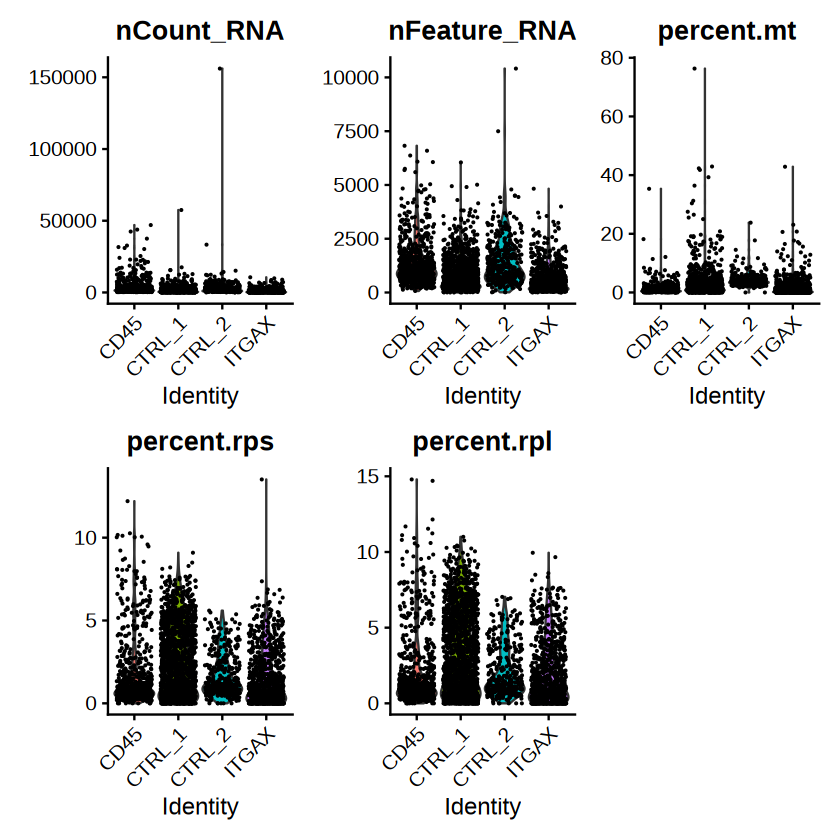

In [11]:
p1 <- VlnPlot(seurat_obj, 
              features = c("nCount_RNA", "nFeature_RNA", "percent.mt", "percent.rps", "percent.rpl"),
              group.by = "sample", 
              ncol= 3,
              pt.size = 0.1)



ggsave(
  filename = file.path(FIGURE_DIR, "mIEC_seurat_QC_before_filtering_violin.png"),
  plot = p1,
  width = 14,
  height = 12,
  dpi = 300
)
p1

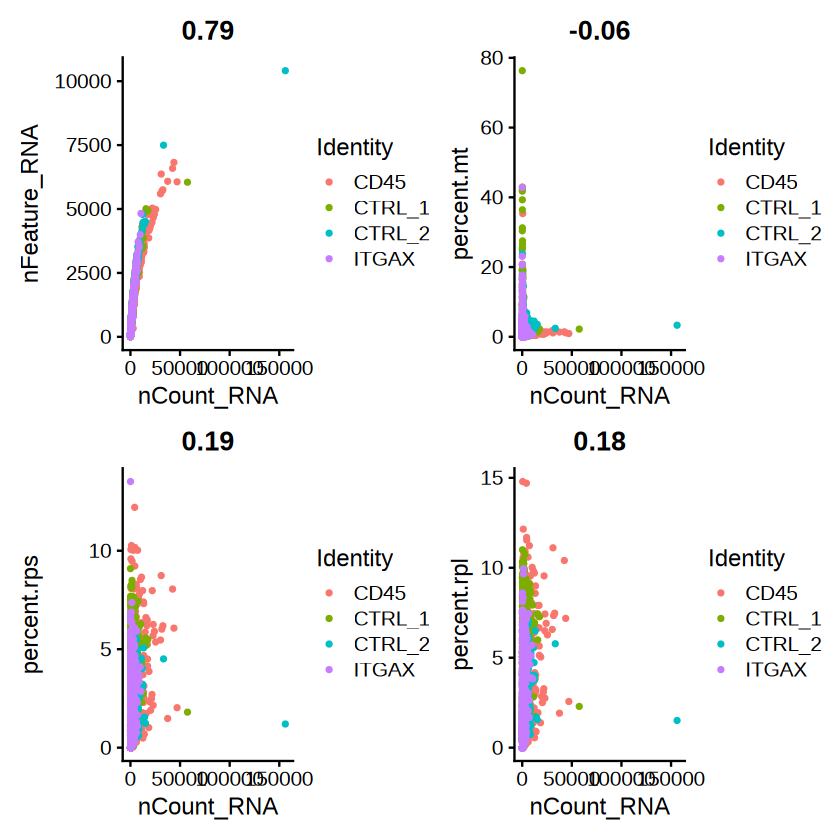

In [12]:
p_counts_features <- FeatureScatter(seurat_obj, feature1 = "nCount_RNA", feature2 = "nFeature_RNA", group.by = "sample")
p_counts_mt <- FeatureScatter(seurat_obj, feature1 = "nCount_RNA", feature2 = "percent.mt", group.by = "sample")
p_counts_rps <- FeatureScatter(seurat_obj, feature1 = "nCount_RNA",feature2 = "percent.rps", group.by = "sample")
p_counts_rpl <- FeatureScatter(seurat_obj, feature1 = "nCount_RNA",feature2 = "percent.rpl", group.by = "sample")

qc_scatter <- (p_counts_features | p_counts_mt )/
              (p_counts_rps |  p_counts_rpl)
qc_scatter

ggsave(
  filename = file.path(FIGURE_DIR, "mIEC_seurat_QC_before_filtering_scatter.png"),
  plot = qc_scatter,
  width = 14,
  height = 10,
  dpi = 300
)


# 8. Filter cells and genes

In [13]:
MIN_GENES_PER_CELL <- 200
MAX_GENES_PER_CELL <- 5000
MAX_MT_PERCENT <- 5
MIN_CELLS_PER_GENE <- 3


cells_before_filtering <- ncol(seurat_obj)
genes_before_filtering <- nrow(seurat_obj)

cat("Before filtering:\n")
cat("Cells:", cells_before_filtering, "\n")
cat("Genes:", genes_before_filtering, "\n")


# Cell filtering
seurat_filtered <- subset(
  seurat_obj,
  subset =
    nFeature_RNA >= MIN_GENES_PER_CELL &
    nFeature_RNA <= MAX_GENES_PER_CELL &
    percent.mt <= MAX_MT_PERCENT 
)

cat("After cell filtering:\n")
cat("Cells:", ncol(seurat_filtered), "\n")
cat("Genes:", nrow(seurat_filtered), "\n")


# Join layers for Seurat v5 compatibility
seurat_filtered <- JoinLayers(
  object = seurat_filtered,
  assay = "RNA"
)




Before filtering:
Cells: 3494 
Genes: 21925 
After cell filtering:
Cells: 2741 
Genes: 21925 


In [14]:
# Gene filtering: keep genes detected in at least 3 cells
counts_matrix <- GetAssayData(
  seurat_filtered,
  assay = "RNA",
  layer = "counts"
)

genes_keep <- rowSums(counts_matrix > 0) >= MIN_CELLS_PER_GENE

seurat_filtered <- subset(
  seurat_filtered,
  features = names(genes_keep[genes_keep])
)

cat("After gene filtering:\n")
cat("Cells:", ncol(seurat_filtered), "\n")
cat("Genes:", nrow(seurat_filtered), "\n")


After gene filtering:
Cells: 2741 
Genes: 17464 


In [15]:
# Filtering summary table

filtering_summary <- data.frame(
  filtering_step = "QC_filtering",
  min_genes_per_cell = MIN_GENES_PER_CELL,
  max_genes_per_cell = MAX_GENES_PER_CELL,
  max_mt_percent = MAX_MT_PERCENT,
  min_cells_per_gene = MIN_CELLS_PER_GENE,
  cells_before_filtering = cells_before_filtering,
  cells_after_filtering = ncol(seurat_filtered),
  cells_removed = cells_before_filtering - ncol(seurat_filtered),
  genes_before_filtering = genes_before_filtering,
  genes_after_filtering = nrow(seurat_filtered),
  genes_removed = genes_before_filtering - nrow(seurat_filtered)
)

write.csv(
  filtering_summary,
  file.path(TABLE_DIR, "mIEC_seurat_filtering_summary.csv"),
  row.names = FALSE
)

filtering_summary

filtering_step,min_genes_per_cell,max_genes_per_cell,max_mt_percent,min_cells_per_gene,cells_before_filtering,cells_after_filtering,cells_removed,genes_before_filtering,genes_after_filtering,genes_removed
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
QC_filtering,200,5000,5,3,3494,2741,753,21925,17464,4461


In [16]:
# Filtering summary by sample

cells_per_sample_before <- as.data.frame(table(seurat_obj$sample))
colnames(cells_per_sample_before) <- c("sample", "before_filtering")

cells_per_sample_after <- as.data.frame(table(seurat_filtered$sample))
colnames(cells_per_sample_after) <- c("sample", "after_filtering")

sample_filtering_summary <- merge(
  cells_per_sample_before,
  cells_per_sample_after,
  by = "sample",
  all = TRUE
)

sample_filtering_summary[is.na(sample_filtering_summary)] <- 0

sample_filtering_summary$removed <- (
  sample_filtering_summary$before_filtering -
  sample_filtering_summary$after_filtering
)

sample_filtering_summary$percent_removed <- (
  sample_filtering_summary$removed /
  sample_filtering_summary$before_filtering * 100
)

write.csv(
  sample_filtering_summary,
  file.path(TABLE_DIR, "mIEC_seurat_filtering_summary_by_sample.csv"),
  row.names = FALSE
)

sample_filtering_summary

sample,before_filtering,after_filtering,removed,percent_removed
<fct>,<int>,<int>,<int>,<dbl>
CD45,769,730,39,5.071521
CTRL_1,1474,1147,327,22.184532
CTRL_2,379,304,75,19.788918
ITGAX,872,560,312,35.779817



# 9. QC after filtering

In [17]:
qc_after <- data.frame(
  n_cells_total = ncol(seurat_filtered),
  n_genes_total = nrow(seurat_filtered),
  n_samples = length(unique(seurat_filtered$sample)),
  samples = paste(unique(seurat_filtered$sample), collapse = ", "),
  conditions = paste(unique(seurat_filtered$condition), collapse = ", "),
  n_mt_genes = sum(grepl("^mt-", rownames(seurat_obj))),
  n_rps_genes = sum(grepl("^Rps", rownames(seurat_obj))),
  n_rpl_genes = sum(grepl("^Rpl", rownames(seurat_obj))),
  median_counts_per_cell = median(seurat_filtered$nCount_RNA),
  median_genes_per_cell = median(seurat_filtered$nFeature_RNA),
  median_pct_mt = median(seurat_filtered$percent.mt),
  median_pct_rps = median(seurat_filtered$percent.rps),
  median_pct_rpl = median(seurat_filtered$percent.rpl)
)

write.csv(qc_after, file.path(TABLE_DIR, "04_QC_after_filtering.csv"), row.names = FALSE)
qc_after


n_cells_total,n_genes_total,n_samples,samples,conditions,n_mt_genes,n_rps_genes,n_rpl_genes,median_counts_per_cell,median_genes_per_cell,median_pct_mt,median_pct_rps,median_pct_rpl
<dbl>,<dbl>,<int>,<chr>,<chr>,<int>,<int>,<int>,<dbl>,<int>,<dbl>,<dbl>,<dbl>
2741,17464,4,"CD45, CTRL_1, CTRL_2, ITGAX","CD45, CTRL, ITGAX",11,44,56,1312,833,1.081917,1.485536,1.898734


Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”


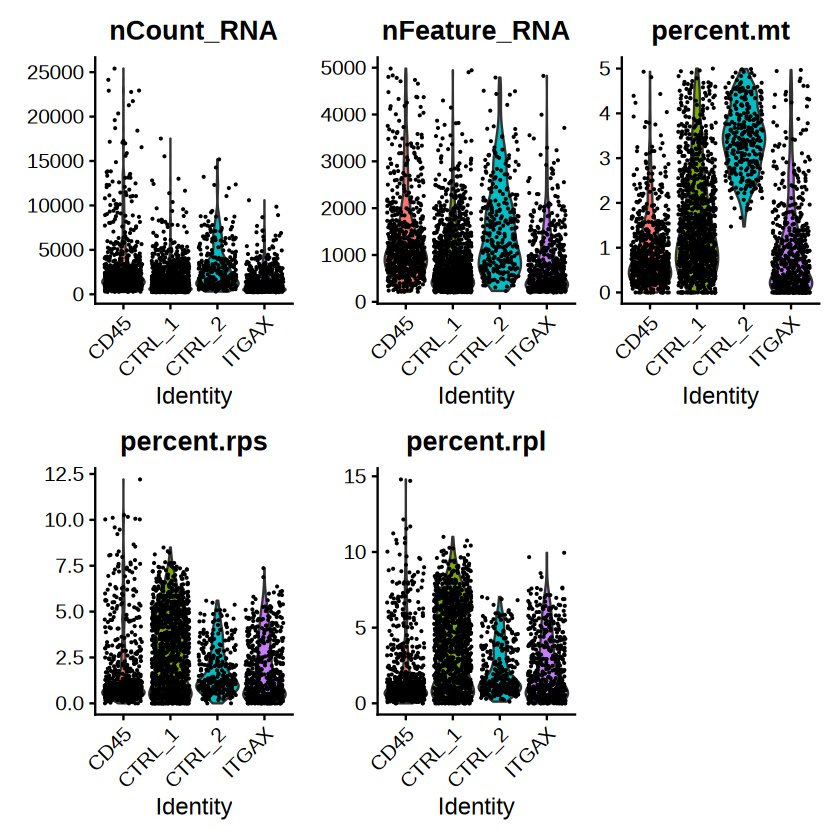

In [18]:
p1 <- VlnPlot(seurat_filtered, 
              features = c("nCount_RNA", "nFeature_RNA", "percent.mt", "percent.rps", "percent.rpl"),
              group.by = "sample", 
              ncol= 3,
              pt.size = 0.1)



ggsave(
  filename = file.path(FIGURE_DIR, "mIEC_seurat_QC_after_filtering_violin.png"),
  plot = p1,
  width = 14,
  height = 12,
  dpi = 300
)
p1

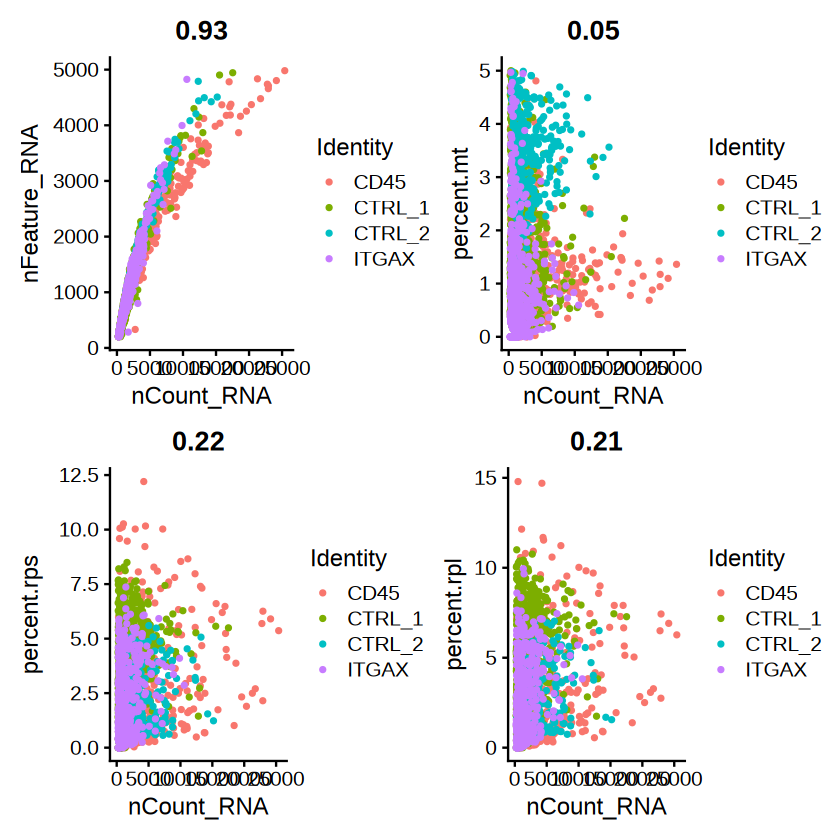

In [19]:
p_counts_features <- FeatureScatter(seurat_filtered, feature1 = "nCount_RNA", feature2 = "nFeature_RNA", group.by = "sample")
p_counts_mt <- FeatureScatter(seurat_filtered, feature1 = "nCount_RNA", feature2 = "percent.mt", group.by = "sample")
p_counts_rps <- FeatureScatter(seurat_filtered, feature1 = "nCount_RNA",feature2 = "percent.rps", group.by = "sample")
p_counts_rpl <- FeatureScatter(seurat_filtered, feature1 = "nCount_RNA",feature2 = "percent.rpl", group.by = "sample")

qc_scatter <- (p_counts_features | p_counts_mt )/
              (p_counts_rps |  p_counts_rpl)
qc_scatter

ggsave(
  filename = file.path(FIGURE_DIR, "mIEC_seurat_QC_after_filtering_scatter.png"),
  plot = qc_scatter,
  width = 14,
  height = 10,
  dpi = 300
)




# 10. Doublet detection with scDblFinder

In [20]:
sce <- as.SingleCellExperiment(seurat_filtered)
sce <- scDblFinder(sce, samples = sce$sample)

seurat_filtered$doublet_score <- sce$scDblFinder.score
seurat_filtered$predicted_doublet <- sce$scDblFinder.class == "doublet"

doublet_summary <- data.frame(
  category = c("singlet", "doublet"),
  n_cells = c(
    sum(!seurat_filtered$predicted_doublet),
    sum(seurat_filtered$predicted_doublet)
  )
)

write.csv(doublet_summary, file.path(TABLE_DIR, "05_doublet_summary.csv"), row.names = FALSE)
doublet_summary

cat("Before doublet removal:", ncol(seurat_filtered), "cells\n")
seurat_filtered <- subset(seurat_filtered, subset = predicted_doublet == FALSE)
cat("After doublet removal:", ncol(seurat_filtered), "cells\n")

Warning message:
“The `slot` argument of `GetAssayData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”
Warning message:
“Layer ‘data’ is empty”
Warning message:
“Layer ‘scale.data’ is empty”
Warning message in .checkSCE(sce):
“Some cells in `sce` have an extremely low read counts; note that these could trigger errors and might best be filtered out”
Warning message in check.deprecation(deprecated_cv_params, match.call(), ...):
“Passed invalid function arguments: max_depth, eval_metric, tree_method, subsample, nthread, eta. These should be passed as a list to argument 'params'. Conversion from argument to 'params' entry will be done automatically, but this behavior will become an error in a future version.”
Warning message in throw_err_or_depr_msg("Parameter(s) have been removed from this function: ", :
“Paramete

category,n_cells
<chr>,<int>
singlet,2656
doublet,85


Before doublet removal: 2741 cells
After doublet removal: 2656 cells


In [21]:
saveRDS(
  seurat_filtered,
  file.path(OBJECT_DIR, "mIEC_seurat_noIntegration_filtered_doublet_removed.rds")
)



# 11. Normalization and highly variable genes

In [22]:
seurat_filtered <- NormalizeData(
  seurat_filtered,
  normalization.method = "LogNormalize",
  scale.factor = 10000
)

seurat_filtered <- FindVariableFeatures(
  seurat_filtered,
  selection.method = "vst",
  nfeatures = 2000
)

hvg_table <- data.frame(gene = VariableFeatures(seurat_filtered))
write.csv(hvg_table, file.path(TABLE_DIR, "06_highly_variable_genes.csv"), row.names = FALSE)

length(VariableFeatures(seurat_filtered))

Normalizing layer: counts

Finding variable features for layer counts



[1] 2000

Warning message in scale_x_log10():
“log-10 transformation introduced infinite values.”
Warning message in scale_x_log10():
“log-10 transformation introduced infinite values.”


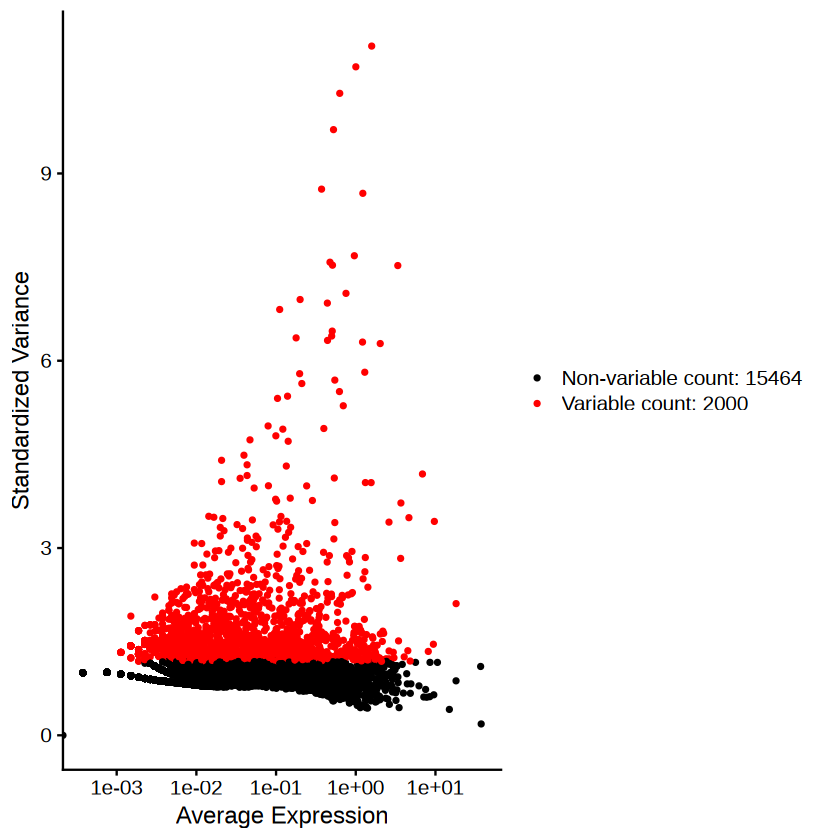

In [23]:
hvg_plot <- VariableFeaturePlot(seurat_filtered)
hvg_plot

ggsave(
  filename = file.path(FIGURE_DIR, "mIEC_seurat_HVGs.png"),
  plot = hvg_plot,
  width = 8,
  height = 5,
  dpi = 300
)


# 12. Scaling and PCA

In [24]:
seurat_filtered <- ScaleData(
  seurat_filtered,
  features = VariableFeatures(seurat_filtered)
)

N_PCS <- 100
seurat_filtered <- RunPCA(
  seurat_filtered,
  features = VariableFeatures(seurat_filtered),
  npcs = N_PCS
)

Centering and scaling data matrix

PC_ 1 
Positive:  Npm1, Hspd1, Gm2000, Rps2, Rps6, Set, Rpl3, Rps23, Ranbp1, Mif 
	   Rpl14, Hmgb2, Rps28, Nop56, Rpl22, Rpl23a, Ppia, Ran, Rps3a1, Lyar 
	   Rps27a, Tubb5, Rpl7, Rpl37, Rps11, Rpl27a, Nolc1, Rpl12, Rpl36a, Rps7 
Negative:  Clec2h, Selenop, Slc51a, Maf, Spink1, Krt20, Apoa1, Tmigd1, Cd74, Ace2 
	   Mep1a, Dpep1, H2-Ab1, Slc34a2, Sis, Slc10a2, Slc13a1, Aspa, Fabp2, Tgfbi 
	   2010106E10Rik, Crip1, Espn, Slc51b, Atf3, Aoc1, Pmp22, H2-Aa, Abcg2, Ces2a 
PC_ 2 
Positive:  Tm4sf4, Pde1c, Cldn4, Ly6m, S100a6, Fcgbp, Ntm, Rhobtb1, Zg16, Sytl2 
	   Clic4, Gm50306, Fer1l6, Srgap1, Oasl1, Egfr, Gcnt3, Kcnb2, Chgb, Cacna2d1 
	   Muc2, 2610035D17Rik, Ptprn2, Gprc5a, Tff3, Chl1, Frmd3, Anxa10, Rab27b, Rab27a 
Negative:  Cox7b, Ccl25, Crip1, Atp5c1, Cox6c, Aoc1, Cox7a2, Spink1, Rps26, Pycard 
	   Mgst1, Oat, Sis, Slc51a, Me2, Sult1b1, Otc, Apol10a, Prxl2b, Uqcrb 
	   Cox8a, Slc51b, Rpl31, Rps27, Rps29, Fabp2, Cyp4f14, Tpt1, Rps3, H2-Ab1 
PC_ 3 
Posit

In [25]:
pca_stdev <- seurat_filtered[["pca"]]@stdev
pca_variance <- pca_stdev^2
pca_variance_ratio <- pca_variance / sum(pca_variance)
pca_variance_percent <- pca_variance_ratio * 100
cumulative_variance_percent <- cumsum(pca_variance_percent)
pcs <- seq_along(pca_variance_percent)

pca_variance_table <- data.frame(
  PC = pcs,
  variance_ratio = pca_variance_ratio,
  variance_percent = pca_variance_percent,
  cumulative_variance_percent = cumulative_variance_percent
)

write.csv(pca_variance_table, file.path(TABLE_DIR, "07_PCA_variance_table.csv"), row.names = FALSE)
head(pca_variance_table, 20)

,PC,variance_ratio,variance_percent,cumulative_variance_percent
,<int>,<dbl>,<dbl>,<dbl>
1,1,0.132439911,13.2439911,13.24399
2,2,0.099482823,9.9482823,23.19227
3,3,0.056639364,5.6639364,28.85621
4,4,0.041852865,4.1852865,33.04150
5,5,0.036867716,3.6867716,36.72827
6,6,0.028195123,2.8195123,39.54778
7,7,0.025027177,2.5027177,42.05050
8,8,0.022258078,2.2258078,44.27631
9,9,0.018364942,1.8364942,46.11280


### Calculate PC Range and Select PCs  manually

In [26]:
pca_stdev <- seurat_filtered@reductions$pca@stdev

pct <- (pca_stdev^2) / sum(pca_stdev^2) * 100
cum <- cumsum(pct)

# Criterion 1:
# first PC where cumulative variance is above 90%
# and individual PC contribution is below 5%
co1 <- which(cum > 90 & pct < 5)[1]

# Criterion 2:
# last major drop in explained variance between consecutive PCs
co2 <- sort(
  which((pct[1:(length(pct) - 1)] - pct[2:length(pct)]) > 0.01),
  decreasing = TRUE
)[1] + 1

# Recommended range
pc_min <- min(co1, co2, na.rm = TRUE)
pc_max <- max(co1, co2, na.rm = TRUE)

cat("Criterion 1 PC:", co1, "\n")
cat("Criterion 2 PC:", co2, "\n")
cat("Recommended PC range:", pc_min, "to", pc_max, "\n")

Criterion 1 PC: 79 
Criterion 2 PC: 34 
Recommended PC range: 34 to 79 


### PCA elbow plot with selected PCs


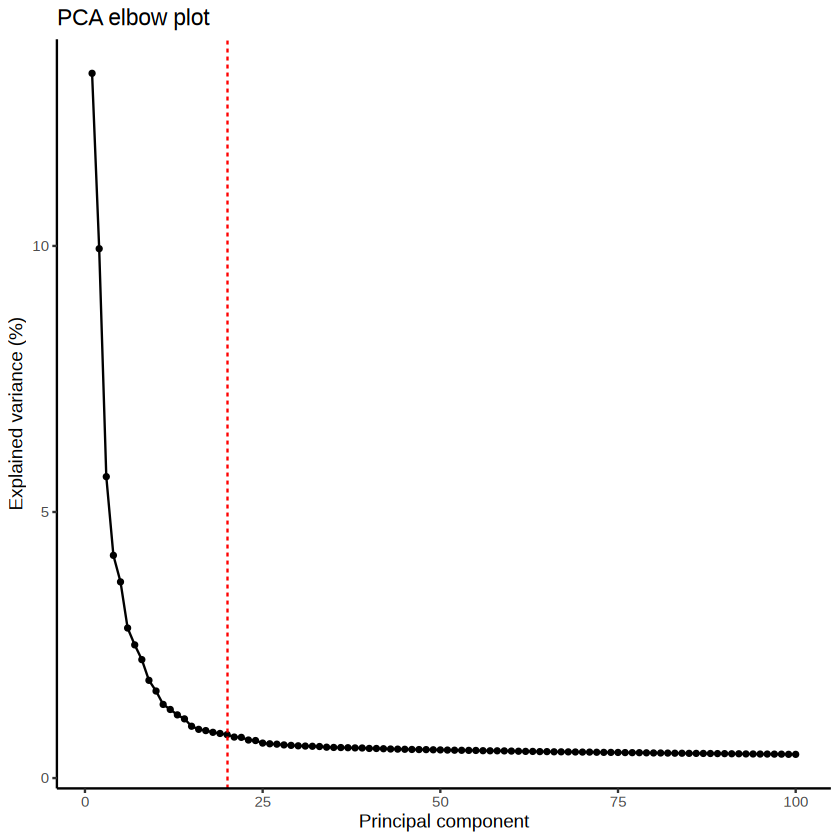

In [27]:
SELECTED_PCS <- 20

elbow_df <- pca_variance_table
p_elbow <- ggplot(elbow_df, aes(x = PC, y = variance_percent)) +
  geom_line() +
  geom_point(size = 1) +
  geom_vline(xintercept = SELECTED_PCS, linetype = "dashed", color = "red") +
  theme_classic() +
  labs(
    title = "PCA elbow plot",
    x = "Principal component",
    y = "Explained variance (%)"
  )

p_elbow

ggsave(
  filename = file.path(FIGURE_DIR, "mIEC_seurat_PCA_elbow_selected_PCs.png"),
  plot = p_elbow,
  width = 8,
  height = 5,
  dpi = 300
)


# 13. Neighbors, UMAP and t-SNE without integration   


In [28]:
seurat_filtered <- FindNeighbors(
  seurat_filtered,
  dims = 1:SELECTED_PCS
)

seurat_filtered <- RunUMAP(
  seurat_filtered,
  dims = 1:SELECTED_PCS
)

seurat_filtered <- RunTSNE(
  seurat_filtered,
  dims = 1:SELECTED_PCS
)

Computing nearest neighbor graph

Computing SNN

Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”
15:24:46 UMAP embedding parameters a = 0.9922 b = 1.112

15:24:46 Read 2656 rows and found 20 numeric columns

15:24:46 Using Annoy for neighbor search, n_neighbors = 30

15:24:46 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

15:24:46 Writing NN index file to temp file /tmp/Rtmp5IAM4p/file9781260e6e87

15:24:46 Searching Annoy index using 1 thread, search_k = 3000

15:24:47 Annoy recall = 100%

15:24:48 Commencing smooth kNN distance cali

### UMAP   


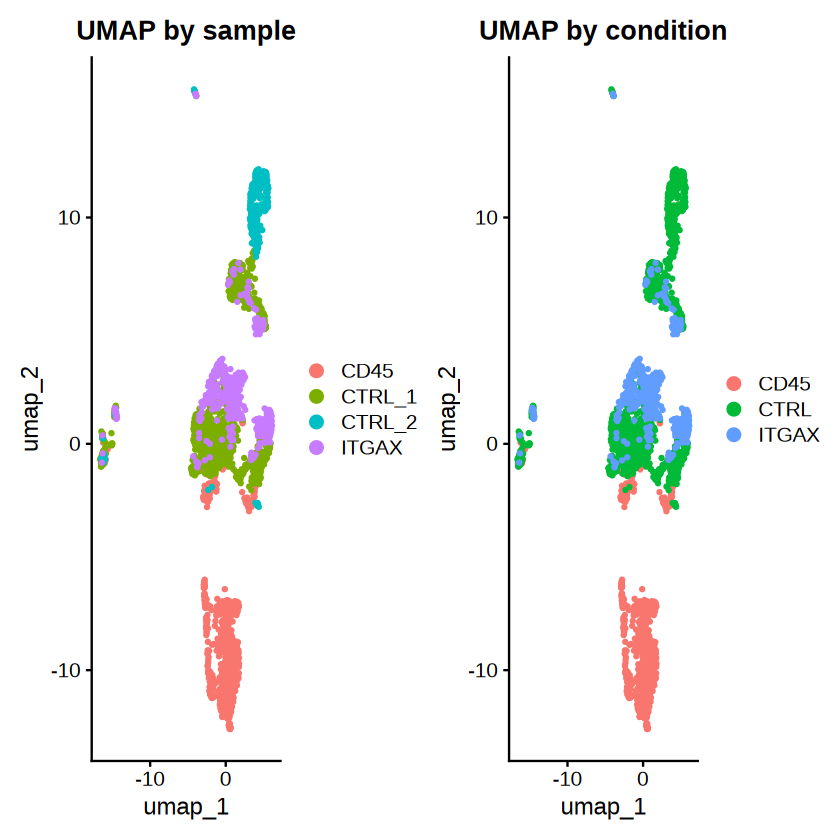

In [29]:
p_umap_sample <- DimPlot(seurat_filtered, reduction = "umap", group.by = "sample") + ggtitle("UMAP by sample")
p_umap_condition <- DimPlot(seurat_filtered, reduction = "umap", group.by = "condition") + ggtitle("UMAP by condition")

p_umap_meta <- p_umap_sample | p_umap_condition
p_umap_meta

ggsave(
  filename = file.path(FIGURE_DIR, "mIEC_seurat_noIntegration_UMAP_sample_condition.png"),
  plot = p_umap_meta,
  width = 12,
  height = 5,
  dpi = 300
)



# 14. Clustering across resolutions

In [30]:
# Clustering across multiple resolutions using Louvain and Leiden

resolutions <- seq(0.1, 1.9, by = 0.1)

# Louvain clustering: algorithm 1
seurat_filtered <- FindClusters(
  seurat_filtered,
  resolution = resolutions,
  algorithm = 1,
  cluster.name = paste0("louvain_res_", resolutions)
)

# Leiden clustering: algorithm 4
seurat_filtered <- FindClusters(
  seurat_filtered,
  resolution = resolutions,
  algorithm = 4,
  cluster.name = paste0("leiden_res_", resolutions)
)


Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 2656
Number of edges: 84519

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9627
Number of communities: 5
Elapsed time: 0 seconds
Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 2656
Number of edges: 84519

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9394
Number of communities: 7
Elapsed time: 0 seconds
Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 2656
Number of edges: 84519

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9228
Number of communities: 10
Elapsed time: 0 seconds
Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 2656
Number of edges: 84519

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9076
Number of communities: 10
Elapsed time: 0 seconds
Modularity Optimizer v

Warning message in RunLeiden(object = object, method = method, partition.type = "RBConfigurationVertexPartition", :
“`random.seed` must be greater than 0 for leiden clustering, resetting `random.seed` to 1.”
Warning message in RunLeiden(object = object, method = method, partition.type = "RBConfigurationVertexPartition", :
“`random.seed` must be greater than 0 for leiden clustering, resetting `random.seed` to 1.”
Warning message in RunLeiden(object = object, method = method, partition.type = "RBConfigurationVertexPartition", :
“`random.seed` must be greater than 0 for leiden clustering, resetting `random.seed` to 1.”
Warning message in RunLeiden(object = object, method = method, partition.type = "RBConfigurationVertexPartition", :
“`random.seed` must be greater than 0 for leiden clustering, resetting `random.seed` to 1.”
Warning message in RunLeiden(object = object, method = method, partition.type = "RBConfigurationVertexPartition", :
“`random.seed` must be greater than 0 for leiden clu

In [31]:
# Create clustering summary with Louvain and Leiden side by side

louvain_columns <- grep("^louvain_res_", colnames(seurat_filtered@meta.data), value = TRUE)
leiden_columns <- grep("^leiden_res_", colnames(seurat_filtered@meta.data), value = TRUE)

louvain_summary <- lapply(louvain_columns, function(col) {
  data.frame(
    resolution = as.numeric(gsub("louvain_res_", "", col)),
    louvain_column = col,
    louvain_n_clusters = length(unique(seurat_filtered@meta.data[[col]]))
  )
}) %>% bind_rows()

leiden_summary <- lapply(leiden_columns, function(col) {
  data.frame(
    resolution = as.numeric(gsub("leiden_res_", "", col)),
    leiden_column = col,
    leiden_n_clusters = length(unique(seurat_filtered@meta.data[[col]]))
  )
}) %>% bind_rows()

clustering_summary <- full_join(
  louvain_summary,
  leiden_summary,
  by = "resolution"
) %>%
  arrange(resolution)

write.csv(
  clustering_summary,
  file.path(TABLE_DIR, "08_clustering_summary_louvain_leiden.csv"),
  row.names = FALSE
)

clustering_summary

resolution,louvain_column,louvain_n_clusters,leiden_column,leiden_n_clusters
<dbl>,<chr>,<int>,<chr>,<int>
0.1,louvain_res_0.1,5,leiden_res_0.1,5
0.2,louvain_res_0.2,7,leiden_res_0.2,5
0.3,louvain_res_0.3,10,leiden_res_0.3,7
0.4,louvain_res_0.4,10,leiden_res_0.4,7
0.5,louvain_res_0.5,11,leiden_res_0.5,8
0.6,louvain_res_0.6,12,leiden_res_0.6,10
0.7,louvain_res_0.7,12,leiden_res_0.7,11
0.8,louvain_res_0.8,13,leiden_res_0.8,12
0.9,louvain_res_0.9,14,leiden_res_0.9,12


### Louvain clustree

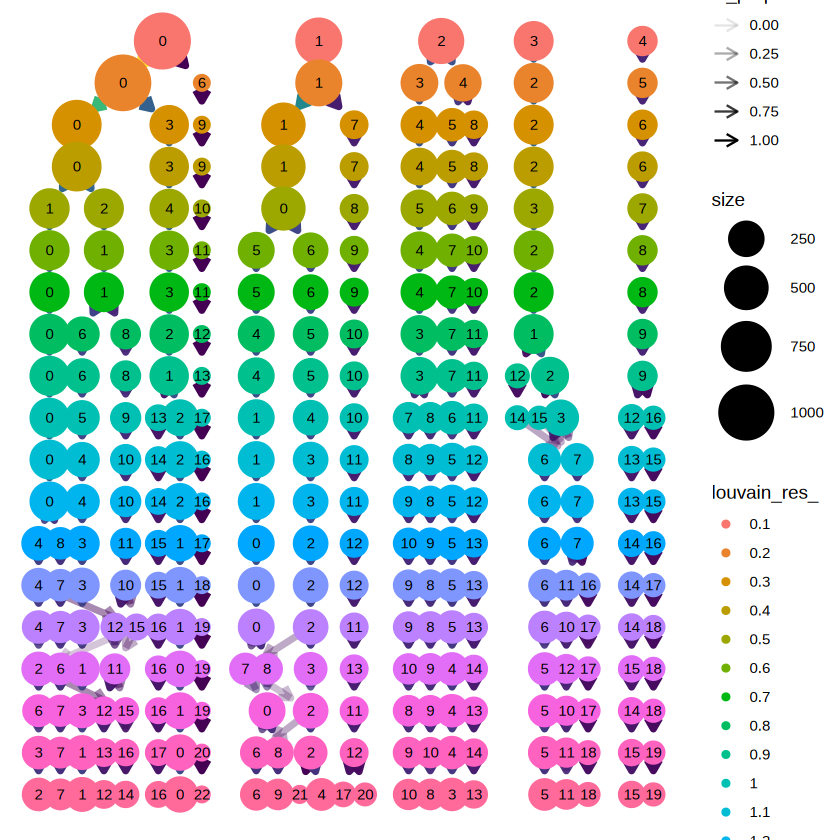

In [32]:
clustree_plot_louvain <- clustree(seurat_filtered@meta.data, prefix = "louvain_res_")
clustree_plot_louvain

ggsave(
  filename = file.path(FIGURE_DIR, "mIEC_seurat_noIntegration_louvain_clustree.png"),
  plot = clustree_plot_louvain,
  width = 12,
  height = 8,
  dpi = 300
)

### Leiden clustree

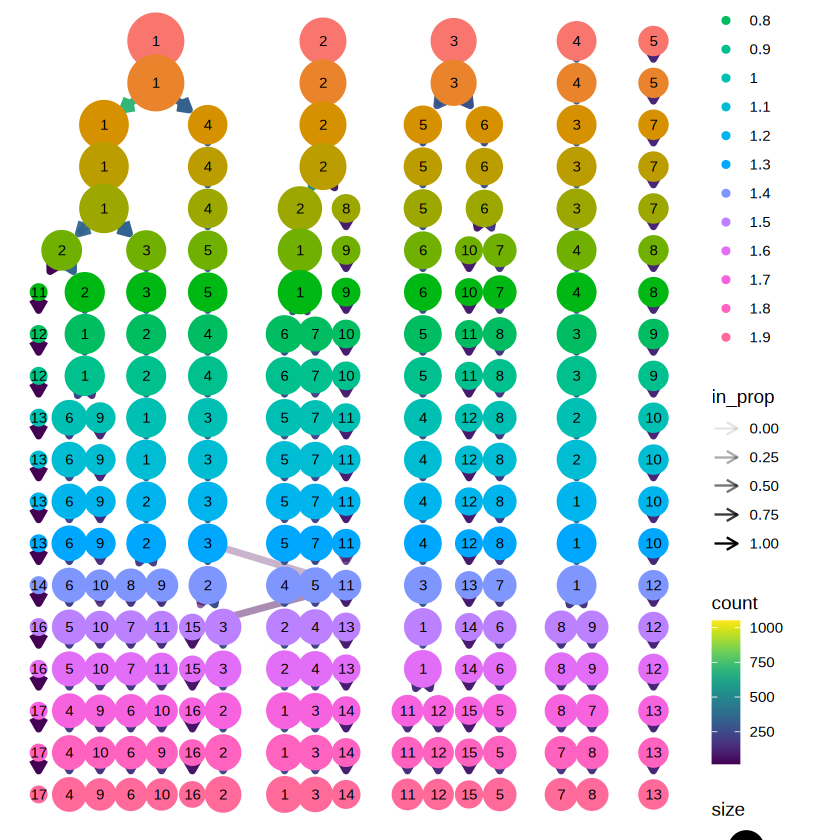

In [33]:
clustree_plot_leiden <- clustree(seurat_filtered@meta.data, prefix = "leiden_res_")
clustree_plot_leiden

ggsave(
  filename = file.path(FIGURE_DIR, "mIEC_seurat_noIntegration_leiden_clustree.png"),
  plot = clustree_plot_leiden,
  width = 12,
  height = 8,
  dpi = 300
)

### Select resolution Louvain

In [34]:
cluster_key_louvain <- "louvain_res_0.4"

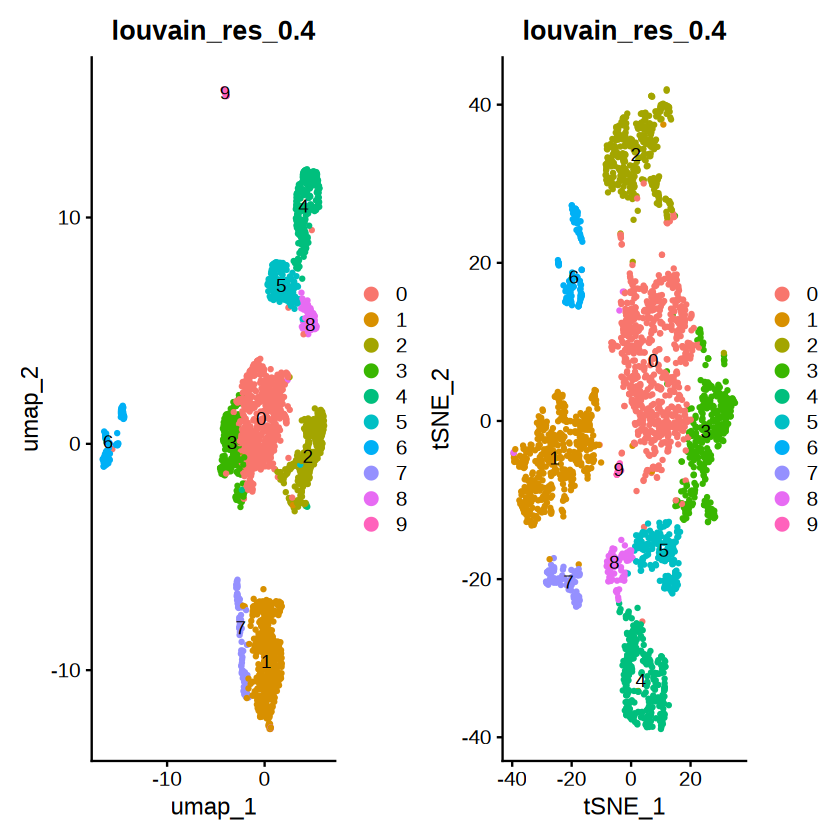

In [35]:
p_final_umap <- DimPlot(seurat_filtered, 
                        reduction = "umap", 
                        group.by = cluster_key_louvain, 
                        label = TRUE) +ggtitle(paste0(cluster_key_louvain))
p_final_tsne <- DimPlot(seurat_filtered, 
                        reduction = "tsne", 
                        group.by = cluster_key_louvain, 
                        label = TRUE) + ggtitle(paste0(cluster_key_louvain))
p_final <- p_final_umap | p_final_tsne
p_final

ggsave(
  filename = file.path(FIGURE_DIR,paste0("mIEC_seurat_noIntegration_",cluster_key_louvain,"_umap_tsne.png")),
  plot = p_final,
  width = 20,
  height = 10,
  dpi = 300
)

### Select resolution Leiden

In [36]:
cluster_key_leiden <- "leiden_res_0.4"

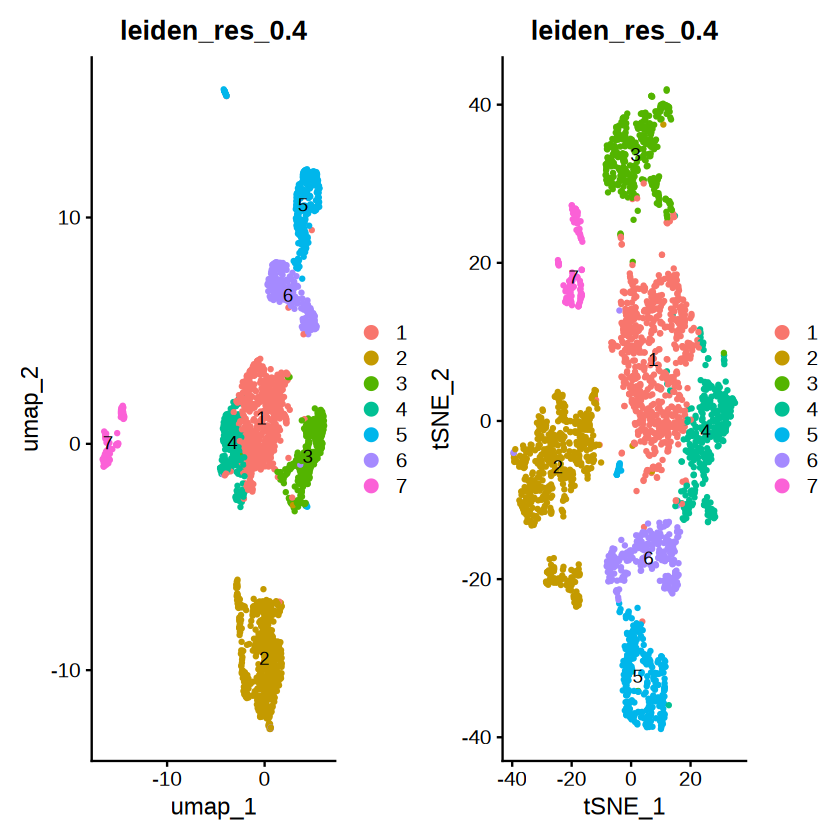

In [37]:
p_final_umap <- DimPlot(seurat_filtered, 
                        reduction = "umap", 
                        group.by = cluster_key_leiden, 
                        label = TRUE) +ggtitle(paste0(cluster_key_leiden))
p_final_tsne <- DimPlot(seurat_filtered, 
                        reduction = "tsne", 
                        group.by = cluster_key_leiden, 
                        label = TRUE) + ggtitle(paste0(cluster_key_leiden))
p_final <- p_final_umap | p_final_tsne
p_final

ggsave(
  filename = file.path(FIGURE_DIR, paste0("mIEC_seurat_noIntegration_",cluster_key_leiden,"_umap_tsne.png")),
  plot = p_final,
  width = 20,
  height = 10,
  dpi = 300
)

## final selected resolution (Louvain 0.4)

In [38]:
cluster_key <- "louvain_res_0.4"

seurat_filtered$final_clusters <- seurat_filtered@meta.data[[cluster_key]]
Idents(seurat_filtered) <- "final_clusters"

table(seurat_filtered$final_clusters)


  0   1   2   3   4   5   6   7   8   9 
699 489 344 331 283 180 122  99  92  17 

## UMAP by condition

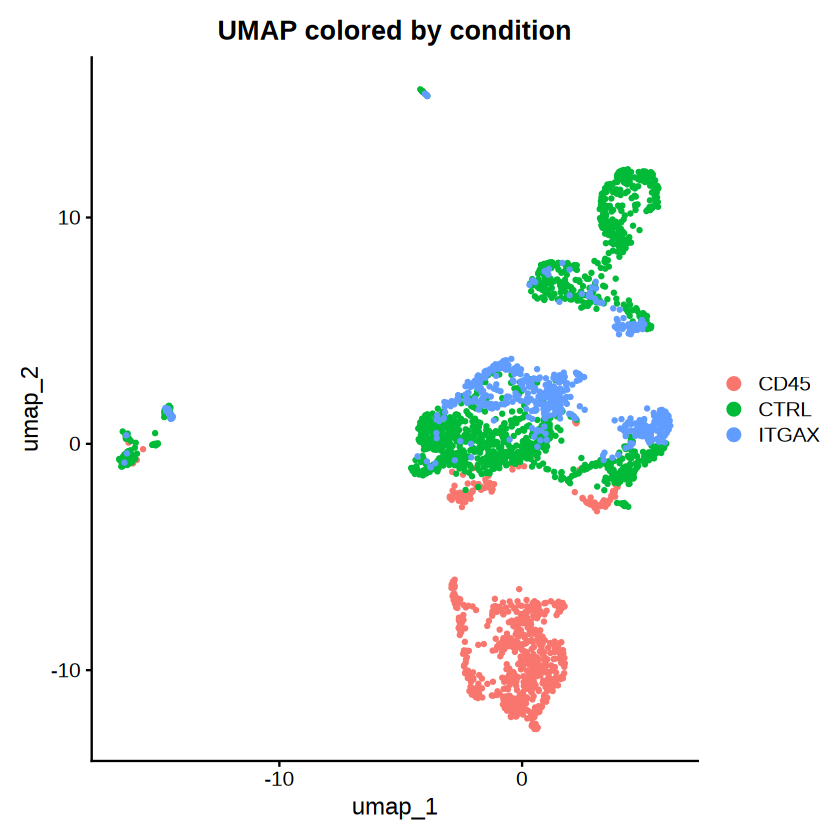

In [39]:
p_umap_condition_only <- DimPlot(
  seurat_filtered,
  reduction = "umap",
  group.by = "condition"
) +
  ggtitle("UMAP colored by condition")

p_umap_condition_only

ggsave(
  filename = file.path(
    FIGURE_DIR,
    "mIEC_seurat_noIntegration_umap_by_condition.png"
  ),
  plot = p_umap_condition_only,
  width = 8,
  height = 6,
  dpi = 300
)

## UMAP by sample  


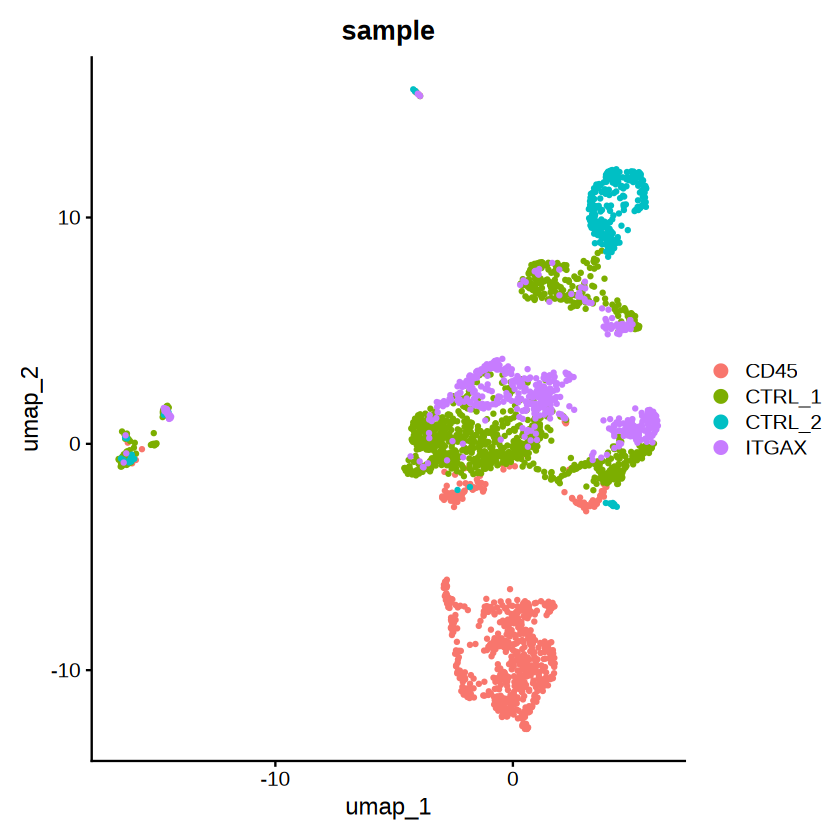

In [40]:
p_umap_by_sample_all <- DimPlot(
  seurat_filtered,
  reduction = "umap",
  group.by = "sample"
) +
  ggtitle("sample")


p_umap_by_sample_all 

ggsave(
  filename = file.path(
    FIGURE_DIR,
    "mIEC_seurat_noIntegration_umap_by_sample_all.png"
  ),
  plot = p_umap_by_sample_all,
  width = 8,
  height = 6,
  dpi = 300
)


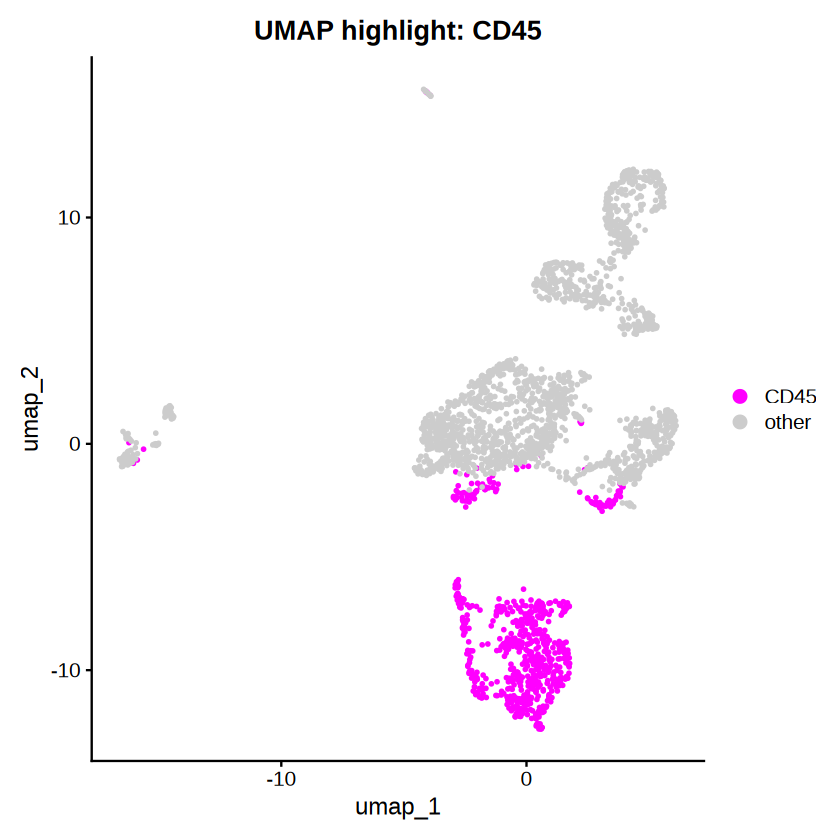

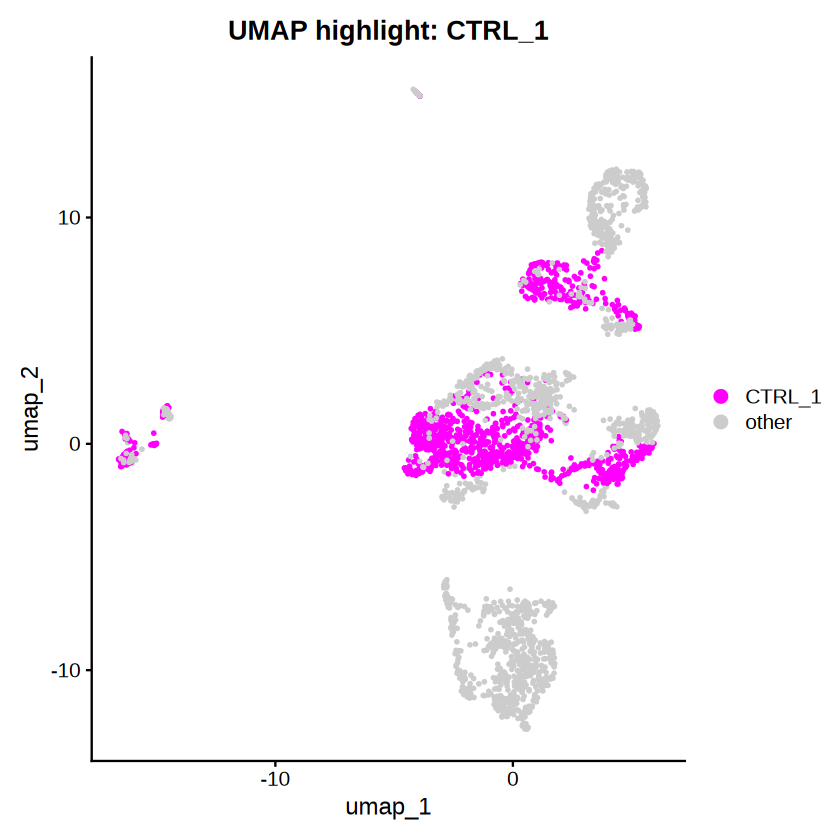

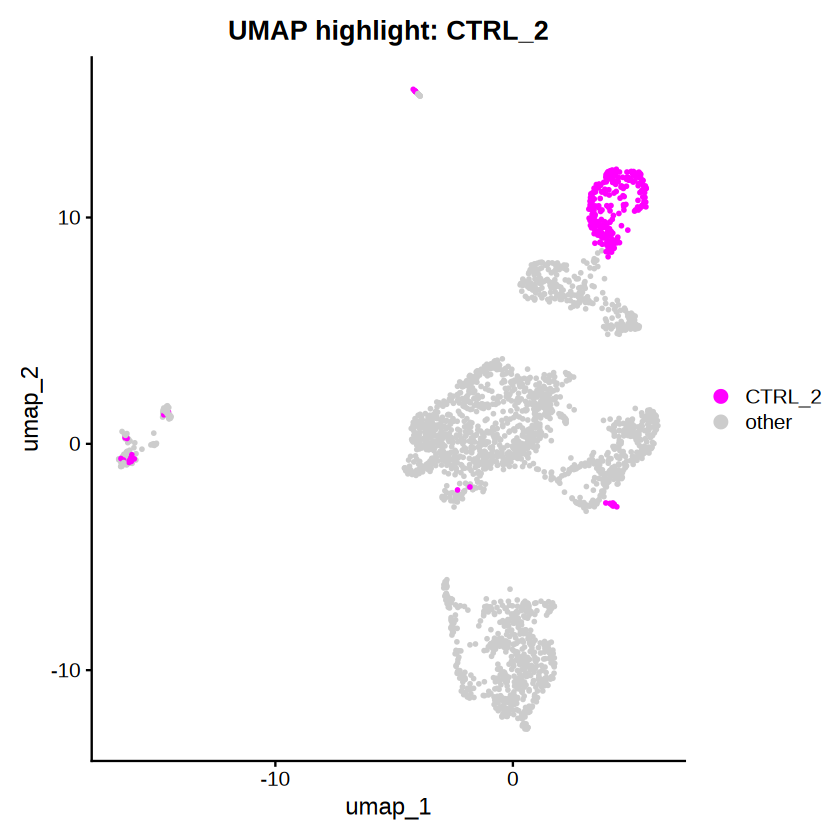

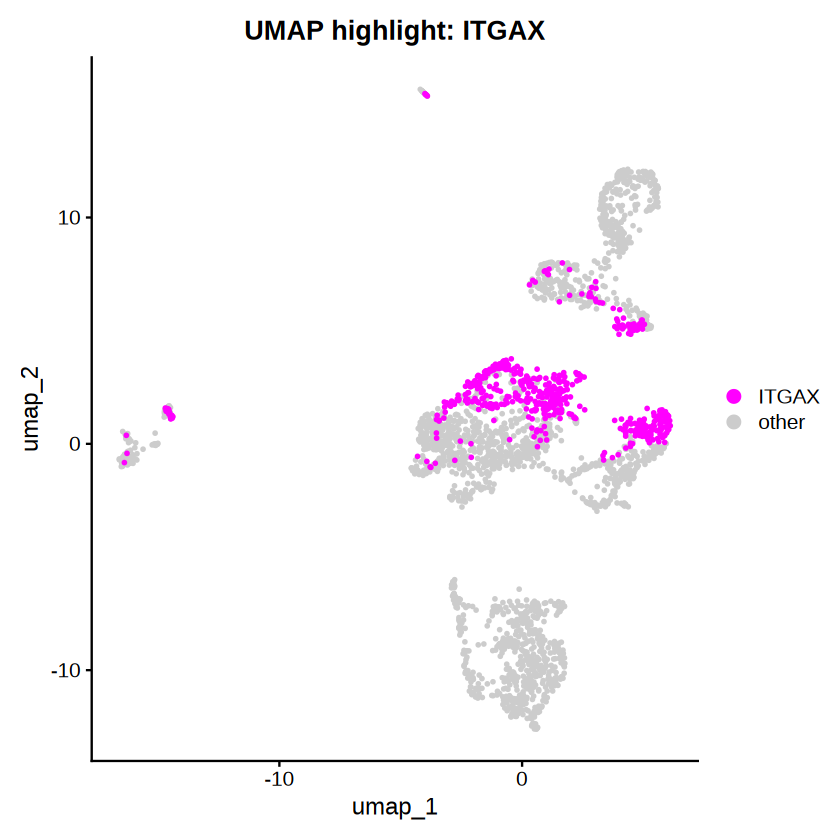

In [41]:
# Highlight each sample separately on the same UMAP

samples <- unique(seurat_filtered$sample)

for (sample_name in samples) {
  
  highlight_column <- paste0("highlight_", sample_name)
  
  seurat_filtered@meta.data[[highlight_column]] <- ifelse(
    seurat_filtered$sample == sample_name,
    sample_name,
    "other"
  )
  
  p_highlight_sample <- DimPlot(
    seurat_filtered,
    reduction = "umap",
    group.by = highlight_column,
    cols = c( "magenta", "grey80"),
    pt.size = 0.4
  ) +
    ggtitle(paste0("UMAP highlight: ", sample_name))
  
  print(p_highlight_sample)
  
  ggsave(
    filename = file.path(
      FIGURE_DIR,
      paste0("mIEC_seurat_noIntegration_umap_highlight_", sample_name, ".png")
    ),
    plot = p_highlight_sample,
    width = 8,
    height = 6,
    dpi = 300
  )
}

## UMAP by final clusters 

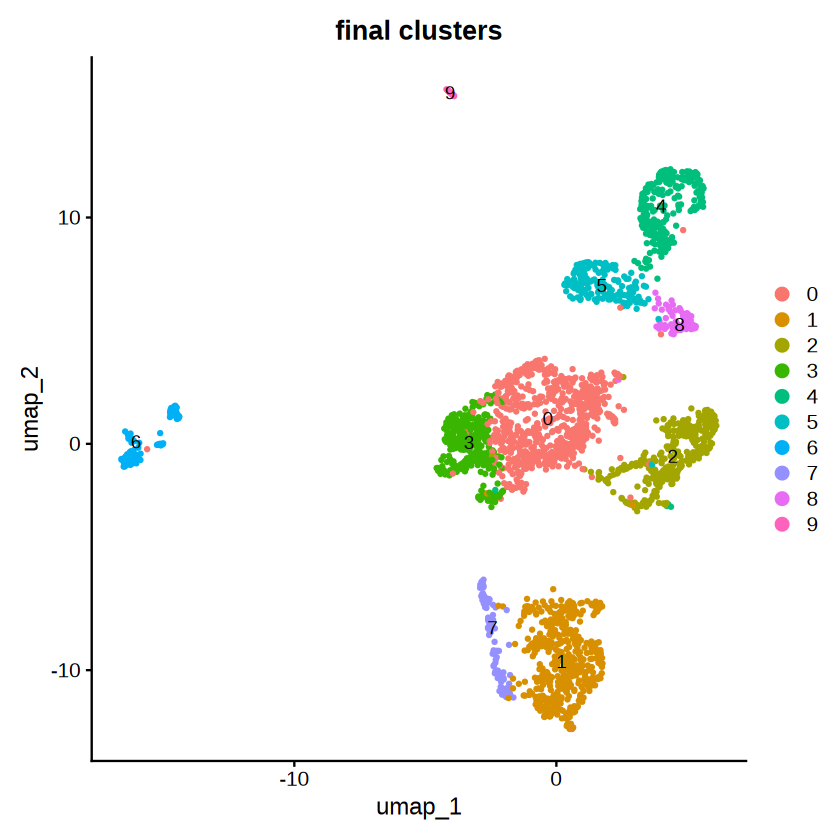

In [42]:
p_umap_clusters_noIntegration <- DimPlot(
  seurat_filtered,
  reduction = "umap",
  group.by = "final_clusters",
  label = TRUE
) +
  ggtitle("final clusters")

p_umap_clusters_noIntegration

ggsave(
  filename = file.path(
    FIGURE_DIR,
    "mIEC_seurat_noIntegration_umap_by_final_clusters.png"
  ),
  plot = p_umap_by_sample_all,
  width = 8,
  height = 6,
  dpi = 300
)

## Combined

In [43]:
# Scanpy-like / thesis-style UMAP theme for Seurat
theme_umap_python_style <- theme_classic(base_size = 12) +
  theme(
    aspect.ratio = 1,
    plot.title = element_text(hjust = 0.5, size = 14),
    axis.title = element_text(size = 13),
    axis.text = element_text(size = 11),
    panel.border = element_rect(color = "black", fill = NA, linewidth = 0.8),
    panel.grid.major = element_line(color = "grey85", linewidth = 0.4),
    panel.grid.minor = element_blank(),
    legend.title = element_blank(),
    legend.text = element_text(size = 11)
  )

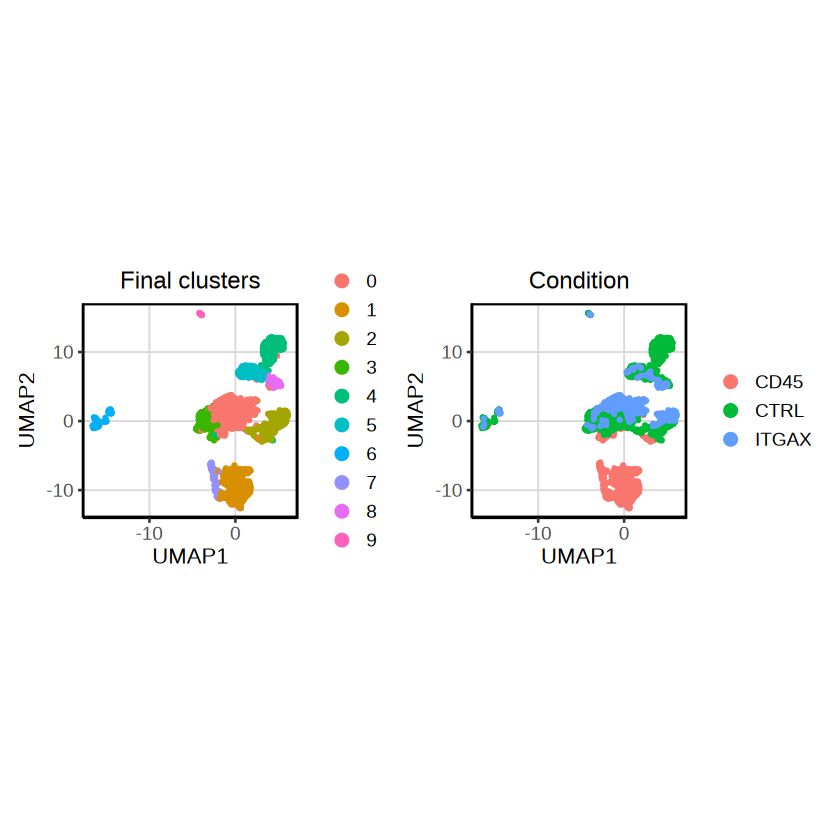

In [44]:
p_no_clusters <- DimPlot(
  seurat_filtered,
  reduction = "umap",
  group.by = "final_clusters",
  label = FALSE,
  pt.size = 0.6
) +
  labs(title = "Final clusters", x = "UMAP1", y = "UMAP2") +
  scale_x_continuous(breaks = c(-10, 0, 10)) +
  scale_y_continuous(breaks = c(-10, 0, 10)) +
  coord_fixed() +
  theme_umap_python_style

p_no_condition <- DimPlot(
  seurat_filtered,
  reduction = "umap",
  group.by = "condition",
  pt.size = 0.6
) +
  labs(title = "Condition", x = "UMAP1", y = "UMAP2") +
  scale_x_continuous(breaks = c(-10, 0, 10)) +
  scale_y_continuous(breaks = c(-10, 0, 10)) +
  coord_fixed() +
  theme_umap_python_style

p_no_combined <- p_no_clusters | p_no_condition

p_no_combined

ggsave(
  filename = file.path(FIGURE_DIR, "mIEC_seurat_noIntegration_combined_umap_python_style.png"),
  plot = p_no_combined,
  width = 14,
  height = 6,
  dpi = 300
)


# 15. Marker genes using all cells and Louvain clusterin resolution 0.4

## scale all genes for better heatmaps

In [45]:
seurat_filtered <- ScaleData(
  seurat_filtered,
  features = rownames(seurat_filtered)
)

Centering and scaling data matrix

Warning message:
“Different features in new layer data than already exists for scale.data”


## find all marker genes

In [46]:
markers <- FindAllMarkers(
  seurat_filtered,
  assay = "RNA",
  only.pos = TRUE,
  test.use = "wilcox",
  logfc.threshold = 0.25,
  min.pct = 0.1
)

markers_filtered <- markers %>%
  filter(p_val_adj < 0.01, avg_log2FC > 0.25)

write.csv(markers, file.path(TABLE_DIR, "09_all_cluster_markers.csv"), row.names = FALSE)
write.csv(markers_filtered, file.path(TABLE_DIR, "10_filtered_cluster_markers.csv"), row.names = FALSE)

cat("all markers before filter:", nrow(markers), "\n")
cat("all markers after filter:", nrow(markers_filtered), "\n")
head(markers_filtered)

Calculating cluster 0

For a (much!) faster implementation of the Wilcoxon Rank Sum Test,
(default method for FindMarkers) please install the presto package
--------------------------------------------
install.packages('devtools')
devtools::install_github('immunogenomics/presto')
--------------------------------------------
After installation of presto, Seurat will automatically use the more 
efficient implementation (no further action necessary).
This message will be shown once per session

Calculating cluster 1

Calculating cluster 2

Calculating cluster 3

Calculating cluster 4

Calculating cluster 5

Calculating cluster 6

Calculating cluster 7

Calculating cluster 8

Calculating cluster 9



all markers before filter: 11354 
all markers after filter: 8335 


,p_val,avg_log2FC,pct.1,pct.2,p_val_adj,cluster,gene
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<chr>
Cdh23,7.595116e-71,1.269382,0.831,0.454,1.326411e-66,0,Cdh23
Hsp90ab1,6.722546e-52,1.117835,0.803,0.687,1.174026e-47,0,Hsp90ab1
Pabpc1,5.001962e-48,1.157500,0.773,0.688,8.735426e-44,0,Pabpc1
Rps19,5.113256e-44,1.272286,0.680,0.495,8.929791e-40,0,Rps19
Ptma,3.846475e-43,1.165212,0.658,0.405,6.717484e-39,0,Ptma
Anxa1,5.381827e-43,3.871014,0.206,0.042,9.398823e-39,0,Anxa1


## select top 15 marke genes

In [47]:
TOP_N <- 15

top15_markers <- markers_filtered %>%
  group_by(cluster) %>%
  arrange(desc(avg_log2FC), .by_group = TRUE) %>%
  slice_head(n = TOP_N) %>%
  ungroup()

top15_genes <- unique(top15_markers$gene)

write.csv(top15_markers, file.path(TABLE_DIR, "11_top15_markers_per_cluster.csv"), row.names = FALSE)


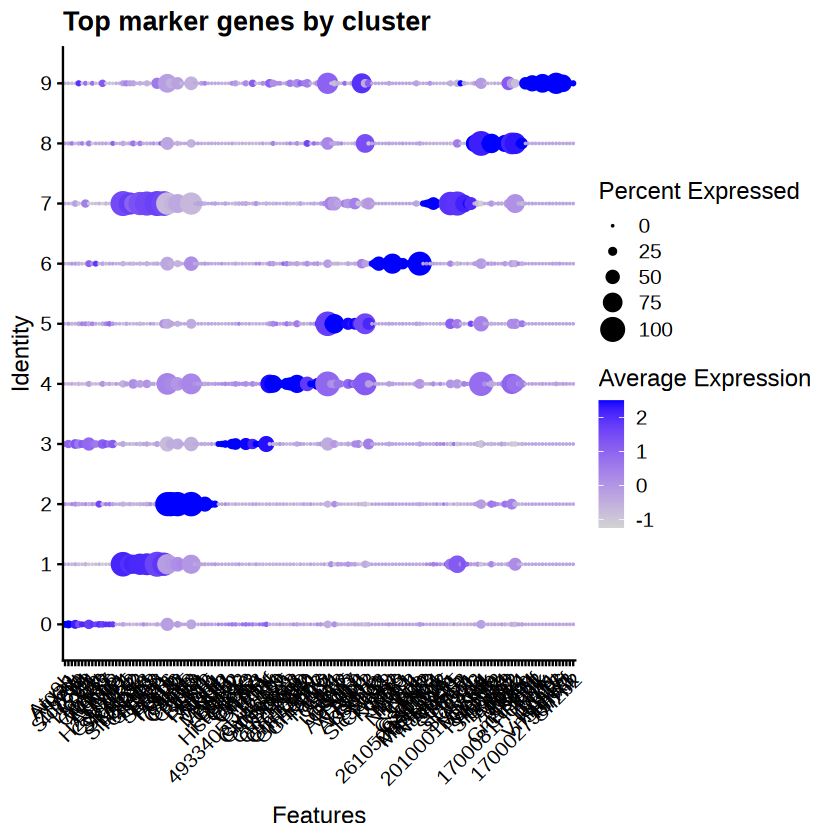

In [48]:
dotplot_markers <- DotPlot(seurat_filtered, features = top15_genes, group.by = "final_clusters") +
  RotatedAxis() +
  ggtitle("Top marker genes by cluster")

dotplot_markers

ggsave(
  filename = file.path(FIGURE_DIR, "mIEC_seurat_noIntegration_top15_markers_dotplot.png"),
  plot = dotplot_markers,
  width = 25,
  height = 10,
  dpi = 300
)

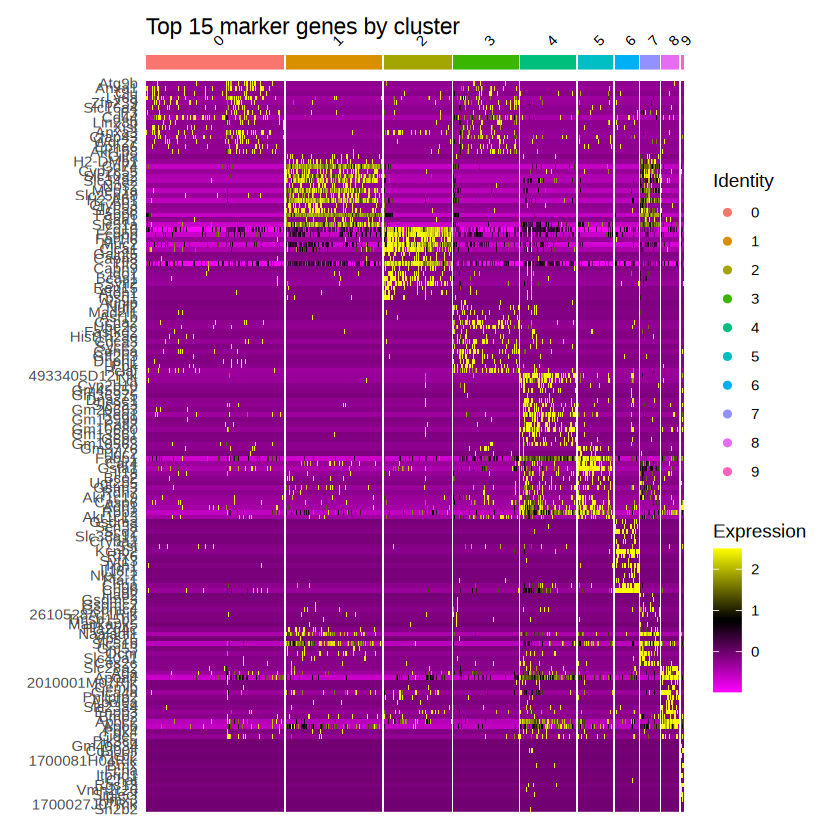

In [49]:
heatmap_markers <- DoHeatmap(
  seurat_filtered,
  features = top15_genes,
  group.by = "final_clusters",
  size = 3
) + ggtitle("Top 15 marker genes by cluster")

heatmap_markers

ggsave(
  filename = file.path(FIGURE_DIR, "mIEC_seurat_noIntegration_top15_markers_heatmap.png"),
  plot = heatmap_markers,
  width = 20,
  height = 14,
  dpi = 300
)


# 16. Feature plots for top markers  


In [50]:
for (cl in sort(unique(as.character(top15_markers$cluster)))) {
  genes_cl <- top15_markers %>%
    filter(as.character(cluster) == cl) %>%
    pull(gene) %>%
    unique()
  
  genes_cl <- genes_cl[genes_cl %in% rownames(seurat_filtered)]
  
  cat("Cluster:", cl, "\n")
  print(genes_cl)
  
  if (length(genes_cl) > 0) {
    p <- FeaturePlot(
      seurat_filtered,
      features = genes_cl,
      reduction = "umap",
      ncol = 4
    )
    
    ggsave(
      filename = file.path(FIGURE_DIR, paste0("mIEC_seurat_noIntegration_cluster_", cl, "_top_marker_featureplots.png")),
      plot = p,
      width = 14,
      height = 10,
      dpi = 300
    )
  }
}

Cluster: 0 
 [1] "Atg9b"   "Anxa1"   "Clu"     "Ly6a"    "Zfp239"  "Slc16a4" "F3"     
 [8] "Cd44"    "Lin28b"  "Xist"    "Anxa3"   "Cfap43"  "Wdr27"   "Epha6"  
[15] "Akr1b8" 
Cluster: 1 
 [1] "Ciita"    "H2-DMb1"  "Cd74"     "Cyp2c55"  "Slc10a2"  "Slc34a2" 
 [7] "Nos2"     "Mep1a"    "Slc25a48" "H2-Ab1"   "Crybb3"   "Slc5a8"  
[13] "Fabp6"    "Saa1"     "Slc51a"  
Cluster: 2 
 [1] "Zg16"   "Fcgbp"  "Fer1l6" "Muc2"   "Clca1"  "Galnt5" "Capn8"  "Tff3"  
 [9] "Capn9"  "Ido1"   "Bcas1"  "Sytl2"  "Rep15"  "Atoh1"  "Tpsg1" 
Cluster: 3 
 [1] "Aunip"     "Nuf2"      "Mad2l1"    "Asf1b"     "Ccna2"     "Ube2c"    
 [7] "Fastkd2"   "Hist1h2ae" "Cdca3"     "Syce2"     "Cenpa"     "Gtf2h3"   
[13] "Dnph1"     "Pbk"       "Pclaf"    
Cluster: 4 
 [1] "4933405D12Rik" "Lct"           "Cyp2b10"       "Gm45552"      
 [5] "Gm36975"       "Dnase1"        "Slc9a3"        "Gm20663"      
 [9] "Reg1"          "Gm12999"       "Patl2"         "Gm10680"      
[13] "Gm13561"       "G6pc"          "Gm10563"  



# 17. Markers by condition  



In [51]:
condition_marker_tables <- list()

MIN_CELLS_PER_CLUSTER <- 10

for (cond in unique(seurat_filtered$condition)) {
  cat("Running marker detection for condition:", cond, "\n")
  
  obj_cond <- subset(seurat_filtered, subset = condition == cond)
  
  cluster_counts <- table(obj_cond$final_clusters)
  valid_clusters <- names(cluster_counts[cluster_counts >= MIN_CELLS_PER_CLUSTER])
  obj_cond <- subset(obj_cond, subset = final_clusters %in% valid_clusters)
  
  if (length(unique(obj_cond$final_clusters)) < 2) {
    cat("Skipped", cond, "- fewer than 2 valid clusters\n")
    next
  }
  
  Idents(obj_cond) <- "final_clusters"
  
  markers_cond <- FindAllMarkers(
    obj_cond,
    assay = "RNA",
    only.pos = TRUE,
    test.use = "wilcox",
    logfc.threshold = 0.25,
    min.pct = 0.1
  )
  
  markers_cond$condition <- cond
  condition_marker_tables[[cond]] <- markers_cond
}

markers_by_condition <- bind_rows(condition_marker_tables)

markers_by_condition_filtered <- markers_by_condition %>%
  filter(p_val_adj < 0.05, avg_log2FC > 0.25)

write.csv(markers_by_condition, file.path(TABLE_DIR, "12_markers_by_condition.csv"), row.names = FALSE)
write.csv(markers_by_condition_filtered, file.path(TABLE_DIR, "13_filtered_markers_by_condition.csv"), row.names = FALSE)

cat("Markers by condition:", nrow(markers_by_condition_filtered), "\n")
head(markers_by_condition_filtered)

Running marker detection for condition: CD45 


Calculating cluster 0

Calculating cluster 1

Calculating cluster 2

Calculating cluster 3

Calculating cluster 7



Running marker detection for condition: CTRL 


Calculating cluster 0

Calculating cluster 2

Calculating cluster 3

Calculating cluster 4

Calculating cluster 5

Calculating cluster 6

Calculating cluster 8



Running marker detection for condition: ITGAX 


Calculating cluster 0

Calculating cluster 2

Calculating cluster 3

Calculating cluster 5

Calculating cluster 6

Calculating cluster 8



Markers by condition: 11698 


,p_val,avg_log2FC,pct.1,pct.2,p_val_adj,cluster,gene,condition
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<chr>,<chr>
Fbn1,9.716677e-17,9.929024,0.103,0.000,1.696921e-12,0,Fbn1,CD45
Pcolce2...2,9.716677e-17,10.538573,0.103,0.000,1.696921e-12,0,Pcolce2,CD45
Timp3,9.716677e-17,9.760104,0.103,0.000,1.696921e-12,0,Timp3,CD45
Ptma...4,7.564063e-14,3.075494,0.759,0.252,1.320988e-09,0,Ptma,CD45
C3,1.189775e-12,8.037072,0.103,0.002,2.077822e-08,0,C3,CD45
Cavin3,1.189775e-12,8.626648,0.103,0.002,2.077822e-08,0,Cavin3,CD45



# 18. Heatmaps per condition  



In [52]:
for (cond in unique(seurat_filtered$condition)) {
  cat("Plotting heatmap for condition:", cond, "\n")
  
  obj_cond <- subset(seurat_filtered, subset = condition == cond)
  
  heatmap_cond <- DoHeatmap(
    obj_cond,
    features = top15_genes,
    group.by = "final_clusters",
    size = 3
  ) + ggtitle(paste("Top marker genes -", cond))
  
  ggsave(
    filename = file.path(FIGURE_DIR, paste0("mIEC_seurat_noIntegration_top15_marker_heatmap_condition_", cond, ".png")),
    plot = heatmap_cond,
    width = 14,
    height = 10,
    dpi = 300
  )
}

Plotting heatmap for condition: CD45 
Plotting heatmap for condition: CTRL 
Plotting heatmap for condition: ITGAX 



# 19. Conserved markers across conditions  


In [53]:
conserved_markers <- markers_by_condition_filtered %>%
  group_by(cluster, gene) %>%
  summarise(
    n_experiments = n_distinct(condition),
    experiments = paste(sort(unique(condition)), collapse = ", "),
    mean_logfoldchange = mean(avg_log2FC, na.rm = TRUE),
    min_logfoldchange = min(avg_log2FC, na.rm = TRUE),
    mean_pvals_adj = mean(p_val_adj, na.rm = TRUE),
    max_pvals_adj = max(p_val_adj, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  filter(
    n_experiments >= 2,
    max_pvals_adj < 0.05,
    min_logfoldchange > 0.25
  ) %>%
  arrange(cluster, desc(n_experiments), desc(mean_logfoldchange))

write.csv(conserved_markers, file.path(TABLE_DIR, "14_conserved_markers.csv"), row.names = FALSE)

cat("Conserved markers:", nrow(conserved_markers), "\n")
head(conserved_markers)

Conserved markers: 2045 


cluster,gene,n_experiments,experiments,mean_logfoldchange,min_logfoldchange,mean_pvals_adj,max_pvals_adj
<fct>,<chr>,<int>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
0,Ptma,3,"CD45, CTRL, ITGAX",1.739932,0.9436806,6.591103e-10,1.320988e-09
0,Rps19,3,"CD45, CTRL, ITGAX",1.525292,1.0074105,4.346602e-05,1.303980e-04
0,Rpl13,3,"CD45, CTRL, ITGAX",1.344562,0.8988309,1.499497e-02,4.498468e-02
0,Rps12,3,"CD45, CTRL, ITGAX",1.321151,0.8605397,2.367481e-03,7.088381e-03
0,Rps8,3,"CD45, CTRL, ITGAX",1.295440,0.7029855,1.330353e-03,3.780408e-03
0,Hsp90ab1,3,"CD45, CTRL, ITGAX",1.289052,0.9560578,1.578467e-03,4.735401e-03


## Select top 15 conserved markers by fold change

In [54]:
TOP_N_CONSERVED <- 15

top15_conserved_by_fc <- conserved_markers %>%
  group_by(cluster) %>%
  arrange(desc(mean_logfoldchange), .by_group = TRUE) %>%
  slice_head(n = TOP_N_CONSERVED) %>%
  ungroup()

write.csv(top15_conserved_by_fc, file.path(TABLE_DIR, "16_top15_conserved_markers_by_foldchange.csv"), row.names = FALSE)

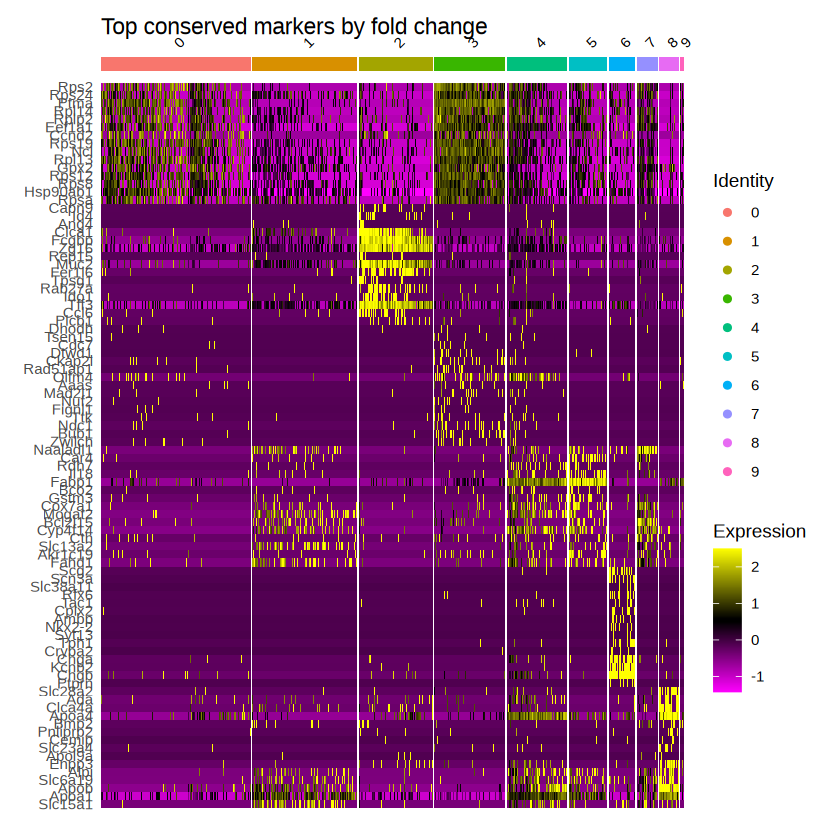

In [55]:
top15_conserved_fc_genes <- unique(top15_conserved_by_fc$gene)

conserved_heatmap <- DoHeatmap(
  seurat_filtered,
  features = top15_conserved_fc_genes,
  group.by = "final_clusters",
  size = 3
) + ggtitle("Top conserved markers by fold change")

conserved_heatmap

ggsave(
  filename = file.path(FIGURE_DIR, "mIEC_seurat_noIntegration_top15_conserved_markers_by_fc_heatmap.png"),
  plot = conserved_heatmap,
  width = 14,
  height = 10,
  dpi = 300
)

## Select top 15 conserved markers by p value

In [56]:
top15_conserved_by_pvalue <- conserved_markers %>%
  group_by(cluster) %>%
  arrange(max_pvals_adj, .by_group = TRUE) %>%
  slice_head(n = TOP_N_CONSERVED) %>%
  ungroup()

write.csv(top15_conserved_by_pvalue, file.path(TABLE_DIR, "15_top15_conserved_markers_by_pvalue.csv"), row.names = FALSE)


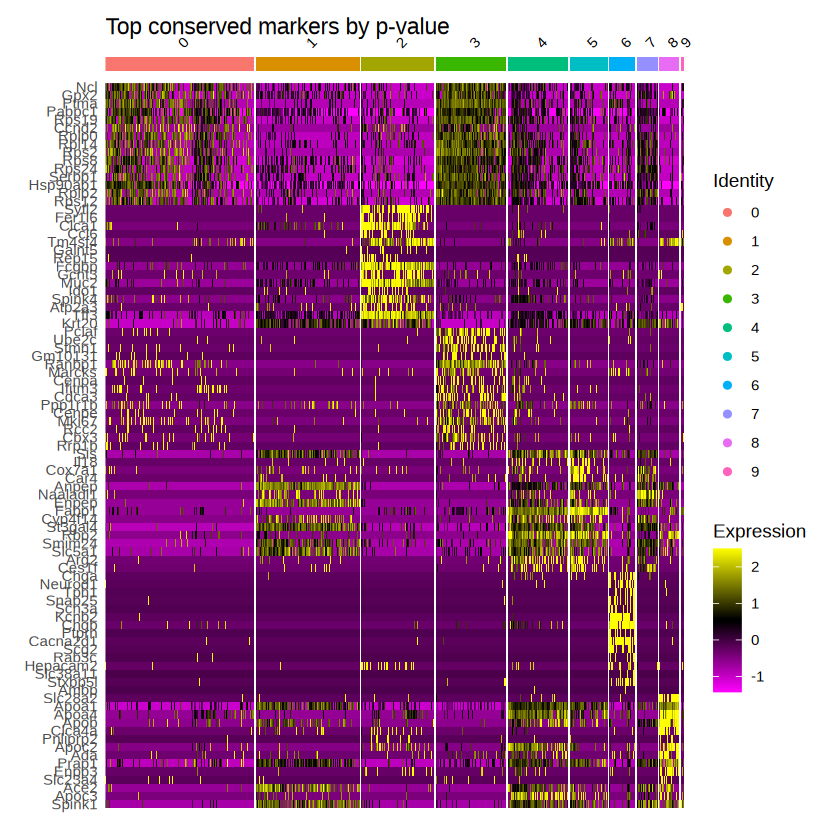

In [57]:
top15_conserved_pvalue_genes <- unique(top15_conserved_by_pvalue$gene)

conserved_heatmap <- DoHeatmap(
  seurat_filtered,
  features = top15_conserved_pvalue_genes,
  group.by = "final_clusters",
  size = 3
) + ggtitle("Top conserved markers by p-value ")

conserved_heatmap

ggsave(
  filename = file.path(FIGURE_DIR, "mIEC_seurat_noIntegration_top15_conserved_markers_by_pvalue_heatmap.png"),
  plot = conserved_heatmap,
  width = 14,
  height = 10,
  dpi = 300
)



# 20. Conserved markers without ribosomal/mitochondrial genes  



In [58]:
conserved_markers_no_ribo <- conserved_markers %>%
  filter(!str_detect(str_to_upper(gene), "^(RPS|RPL|MT-)"))

write.csv(
  conserved_markers_no_ribo,
  file.path(TABLE_DIR, "17_conserved_markers_no_ribo_mt.csv"),
  row.names = FALSE
)

cat("Conserved markers without ribosomal/mitacondrial genes:", nrow(conserved_markers_no_ribo), "\n")
head(conserved_markers_no_ribo)

Conserved markers without ribosomal/mitacondrial genes: 1947 


cluster,gene,n_experiments,experiments,mean_logfoldchange,min_logfoldchange,mean_pvals_adj,max_pvals_adj
<fct>,<chr>,<int>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
0,Ptma,3,"CD45, CTRL, ITGAX",1.739932,0.9436806,6.591103e-10,1.320988e-09
0,Hsp90ab1,3,"CD45, CTRL, ITGAX",1.289052,0.9560578,1.578467e-03,4.735401e-03
0,Eef1a1,2,"CD45, ITGAX",1.547287,1.2227431,2.271720e-02,4.542937e-02
0,Ccnd2,2,"CTRL, ITGAX",1.529815,1.5216188,2.999199e-04,5.981378e-04
0,Ncl,2,"CTRL, ITGAX",1.372478,1.1262978,2.783698e-11,5.567377e-11
0,Gpx2,2,"CTRL, ITGAX",1.322055,1.0960566,2.927836e-10,5.779754e-10



# 21. Stress signature  


In [59]:
stress_genes_input <- c("Bcl2", "Tnf", "Trp53", "Casp3", "Bax", "Casp8", "Fas")
stress_genes <- stress_genes_input[stress_genes_input %in% rownames(seurat_filtered)]
missing_stress_genes <- setdiff(stress_genes_input, stress_genes)

cat("Stress genes found:", paste(stress_genes, collapse = ", "), "\n")
cat("Stress genes missing:", paste(missing_stress_genes, collapse = ", "), "\n")

if (length(stress_genes) == 0) {
  stop("No stress genes were found. Check gene naming.")
}

seurat_filtered <- AddModuleScore(
  seurat_filtered,
  features = list(stress_genes),
  name = "stress_signature"
)

# Seurat appends 1 to the module score name
seurat_filtered$stress_signature <- seurat_filtered$stress_signature1
head(seurat_filtered@meta.data[, c("stress_signature")])

Stress genes found: Bcl2, Tnf, Trp53, Casp3, Bax, Casp8, Fas 
Stress genes missing:  


[1]  0.161574263 -0.002387462  0.102143204  0.016522024  0.072571499
[6] -0.073844029

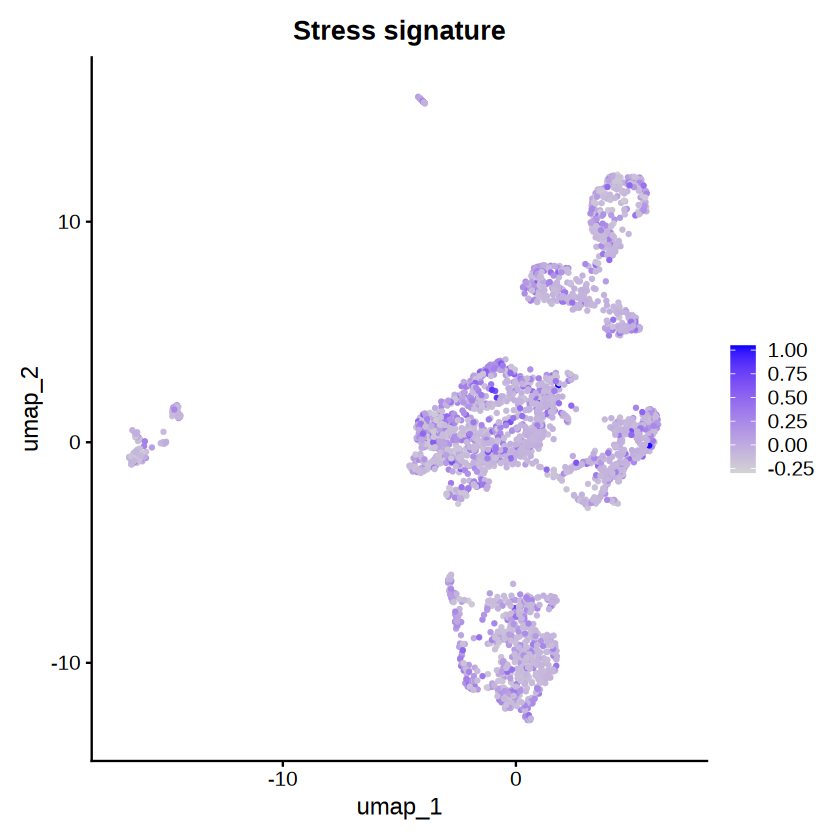

In [60]:
stress_umap <- FeaturePlot(
  seurat_filtered,
  features = "stress_signature",
  reduction = "umap"
) + ggtitle("Stress signature")

stress_umap

ggsave(
  filename = file.path(FIGURE_DIR, "mIEC_seurat_noIntegration_stress_signature_umap.png"),
  plot = stress_umap,
  width = 7,
  height = 6,
  dpi = 300
)


# 22. Stress signature by cluster

In [61]:
stress_by_cluster <- seurat_filtered@meta.data %>%
  group_by(final_clusters) %>%
  summarise(
    count = n(),
    mean = mean(stress_signature, na.rm = TRUE),
    median = median(stress_signature, na.rm = TRUE),
    min = min(stress_signature, na.rm = TRUE),
    max = max(stress_signature, na.rm = TRUE),
    .groups = "drop"
  )

write.csv(stress_by_cluster, file.path(TABLE_DIR, "18_stress_signature_by_cluster.csv"), row.names = FALSE)
stress_by_cluster

final_clusters,count,mean,median,min,max
<fct>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
0,699,0.0301406042,-0.06771797,-0.2204258,1.0489038
1,489,-0.0162635096,-0.09275010,-0.2449630,0.7135995
2,344,-0.0002580465,-0.06937172,-0.2105826,1.0244548
3,331,0.0385204982,0.01817283,-0.2947859,0.7088205
4,283,-0.0394805979,-0.09326864,-0.2954774,0.5717188
5,180,0.0150000400,-0.06367532,-0.1872325,0.5925021
6,122,-0.0387404810,-0.08672726,-0.2375295,0.6174805
7,99,0.0755173971,0.07903704,-0.2109090,0.4772171
8,92,0.0205912047,-0.05389071,-0.1773663,0.5488811


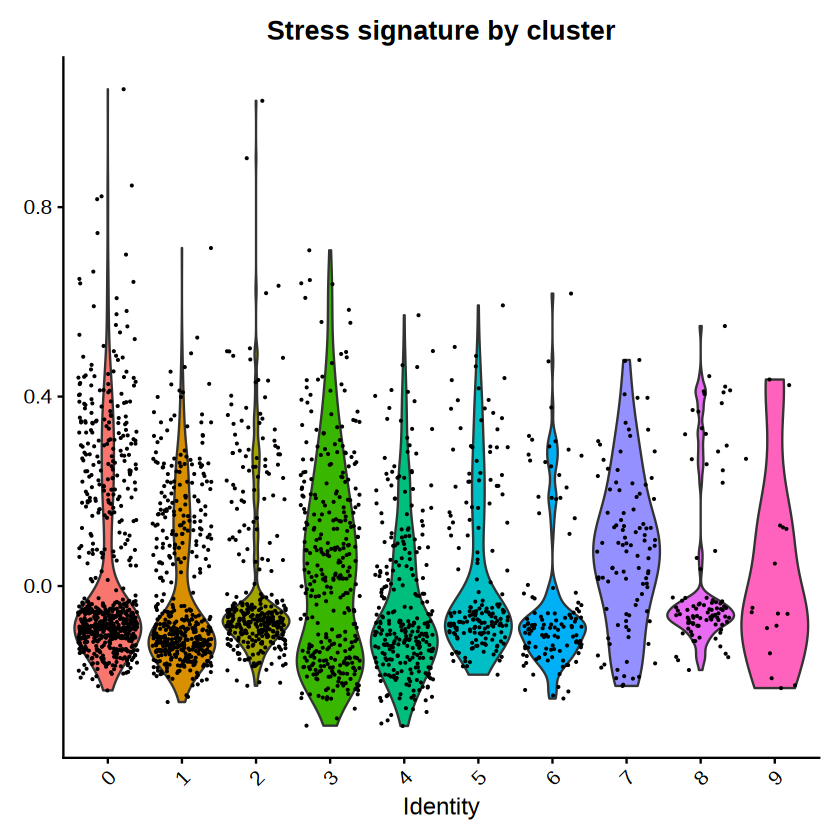

In [62]:

p_cluster_violin <- VlnPlot(
  seurat_filtered,
  features = "stress_signature",
  group.by = "final_clusters",
  pt.size = 0.1
) + NoLegend() + ggtitle("Stress signature by cluster")

p_cluster_violin

ggsave(
  filename = file.path(FIGURE_DIR, "mIEC_seurat_noIntegration_stress_signature_by_cluster.png"),
  plot = p_cluster_violin,
  width = 12,
  height = 5,
  dpi = 300
)

# 23. Stress signature by condition

In [63]:
stress_by_condition <- seurat_filtered@meta.data %>%
  group_by(condition) %>%
  summarise(
    count = n(),
    mean = mean(stress_signature, na.rm = TRUE),
    median = median(stress_signature, na.rm = TRUE),
    min = min(stress_signature, na.rm = TRUE),
    max = max(stress_signature, na.rm = TRUE),
    .groups = "drop"
  )

write.csv(stress_by_condition, file.path(TABLE_DIR, "19_stress_signature_by_condition.csv"), row.names = FALSE)
stress_by_condition

condition,count,mean,median,min,max
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
CD45,708,0.0002442088,-0.07755014,-0.2449630,0.8455743
CTRL,1404,0.0044943824,-0.06932676,-0.2954774,1.0244548
ITGAX,544,0.0291561762,-0.06160423,-0.2204258,1.0489038


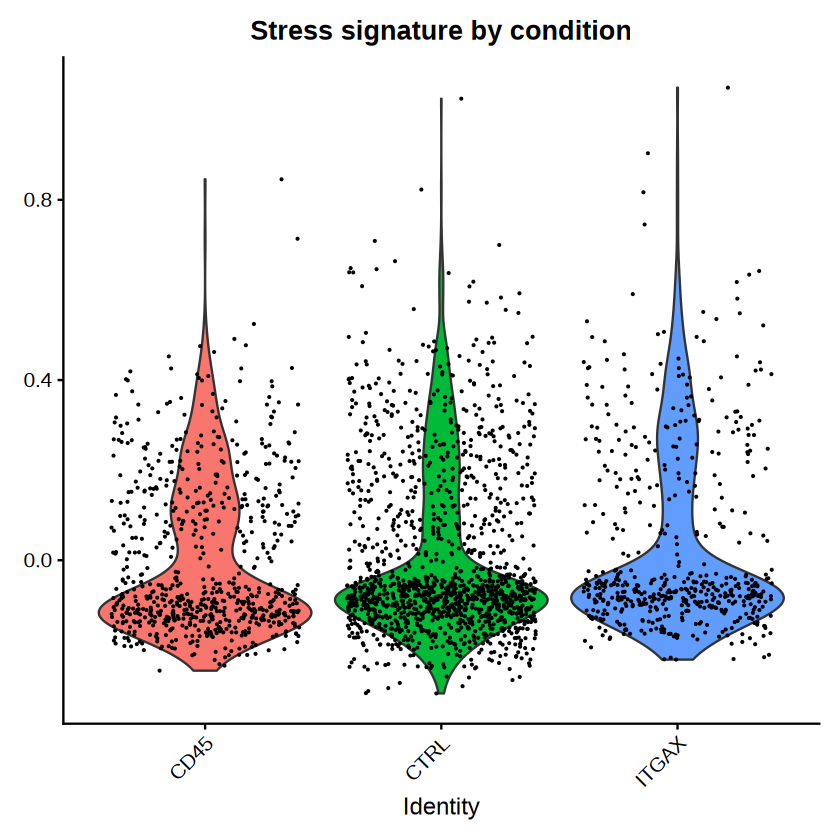

In [64]:
p_condition_violin <- VlnPlot(
  seurat_filtered,
  features = "stress_signature",
  group.by = "condition",
  pt.size = 0.1
) + NoLegend() + ggtitle("Stress signature by condition")

p_condition_violin

ggsave(
  filename = file.path(FIGURE_DIR, "mIEC_seurat_noIntegration_stress_signature_by_condition.png"),
  plot = p_condition_violin,
  width = 10,
  height = 5,
  dpi = 300
)

# 24. Stress signature by cluster and condition  
A high score in a specific cluster-condition group may indicate a stressed subpopulation or condition-specific stress/injury response.


In [65]:
stress_by_cluster_condition <- seurat_filtered@meta.data %>%
  group_by(final_clusters, condition) %>%
  summarise(
    count = n(),
    mean = mean(stress_signature, na.rm = TRUE),
    median = median(stress_signature, na.rm = TRUE),
    min = min(stress_signature, na.rm = TRUE),
    max = max(stress_signature, na.rm = TRUE),
    .groups = "drop"
  )

write.csv(stress_by_cluster_condition, file.path(TABLE_DIR, "20_stress_signature_by_cluster_condition.csv"), row.names = FALSE)
stress_by_cluster_condition

final_clusters,condition,count,mean,median,min,max
<fct>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
0,CD45,29,0.050123136,-0.055060366,-0.19057808,0.8455743
0,CTRL,378,0.010157729,-0.074920445,-0.21143075,0.8227678
0,ITGAX,292,0.054024280,-0.055968438,-0.22042582,1.0489038
1,CD45,489,-0.016263510,-0.092750105,-0.24496304,0.7135995
2,CD45,47,-0.051367158,-0.095123573,-0.20306149,0.4018021
2,CTRL,168,-0.001137313,-0.062447699,-0.21058264,1.0244548
2,ITGAX,129,0.019508193,-0.069353044,-0.16895441,0.9032418
3,CD45,31,0.045132291,0.023439862,-0.22107740,0.4257912
3,CTRL,273,0.048916576,0.028577220,-0.29478594,0.7088205


In [66]:
stress_matrix <- stress_by_cluster_condition %>%
  select(final_clusters, condition, mean) %>%
  pivot_wider(names_from = condition, values_from = mean) %>%
  column_to_rownames("final_clusters") %>%
  as.matrix()

pheatmap(
  stress_matrix,
  cluster_rows = FALSE,
  cluster_cols = FALSE,
  main = "Mean stress signature by cluster and condition",
  filename = file.path(FIGURE_DIR, "mIEC_seurat_noIntegration_stress_signature_cluster_condition_heatmap.png"),
  width = 7,
  height = 5
)

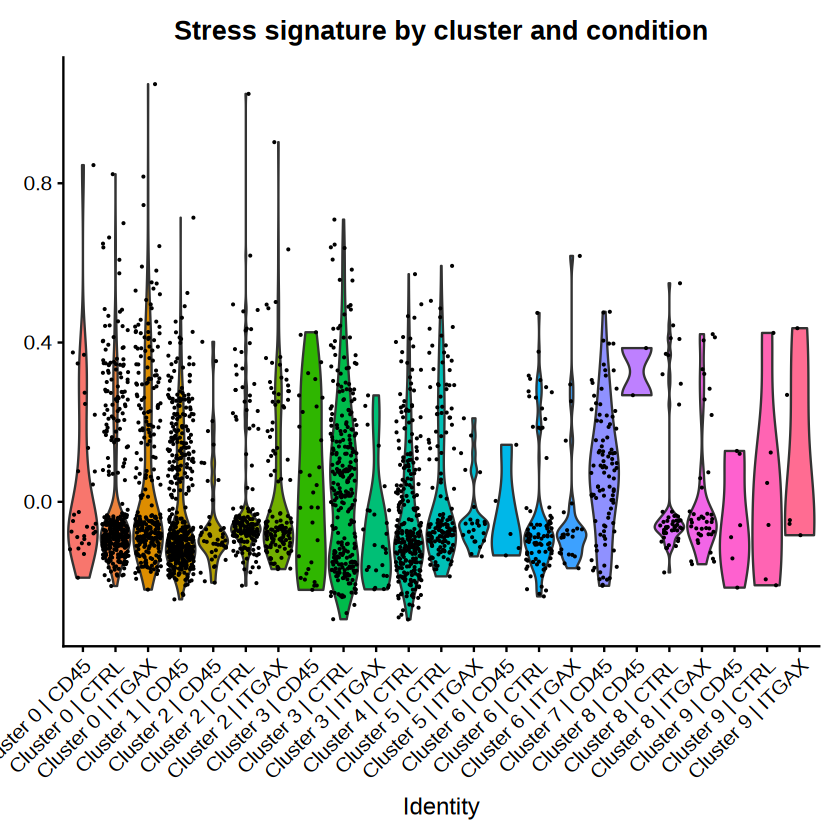

In [67]:
seurat_filtered$cluster_condition <- paste0(
  "Cluster ", seurat_filtered$final_clusters,
  " | ", seurat_filtered$condition
)

p_cluster_condition_violin <- VlnPlot(
  seurat_filtered,
  features = "stress_signature",
  group.by = "cluster_condition",
  pt.size = 0.1
) +
  NoLegend() +
  RotatedAxis() +
  ggtitle("Stress signature by cluster and condition")

p_cluster_condition_violin

ggsave(
  filename = file.path(FIGURE_DIR, "mIEC_seurat_noIntegration_stress_signature_cluster_condition_violin.png"),
  plot = p_cluster_condition_violin,
  width = 18,
  height = 7,
  dpi = 300
)

## check default assay

In [68]:
cat("Current default assay:", DefaultAssay(seurat_filtered), "\n")

Current default assay: RNA 



# 25. Save final object and session info

In [69]:
final_object <- file.path(
  OBJECT_DIR,
  "mIEC_seurat_noIntegration_processed_final_with_markers_stress.rds"
)

saveRDS(seurat_filtered, final_object)
cat("Saved final object:", final_object, "\n")

Saved final object: /CEPH/users/mtarzi/scRNA_sequencing_of_murine_intestinal_epithelial/seurat_noIntegration/objects/mIEC_seurat_noIntegration_processed_final_with_markers_stress.rds 


In [70]:
runtime <- Sys.time() - workflow_start

runtime_table <- data.frame(
  workflow = "Seurat_noIntegration",
  runtime_seconds = as.numeric(runtime, units = "secs"),
  runtime_minutes = as.numeric(runtime, units = "mins")
)

write.csv(runtime_table, file.path(TABLE_DIR, "21_seurat_noIntegration_runtime_summary.csv"), row.names = FALSE)

sink(file.path(TABLE_DIR, "22_R_noIntegration_session_info.txt"))
cat("R session information\n")
cat("=====================\n")
print(sessionInfo())
sink()

runtime_table

workflow,runtime_seconds,runtime_minutes
<chr>,<dbl>,<dbl>
Seurat_noIntegration,428.8084,7.146807


## 